In [ ]:
!nvidia-smi

Sun Dec 28 12:36:04 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Pre-processing

In [ ]:
import pandas as pd

df = pd.read_csv(
    "/content/drive/MyDrive/CyberSecurity/RS_Session_265_AU_1907_A.csv"
)

In [ ]:
display(df)

,Sl. No.,State/UT,Cases Reported - 2018,Cases Reported - 2019,Cases Reported - 2020,Cases Reported - 2021,Cases Reported - 2022
0,1,Andhra Pradesh,240.0,245.0,171,168,163
1,2,Arunachal Pradesh,3.0,0.0,2,3,4
2,3,Assam,308.0,201.0,124,203,140
3,4,Bihar,127.0,106.0,75,111,260
4,5,Chhattisgarh,51.0,50.0,38,29,26
5,6,Goa,55.0,38.0,17,15,1
6,7,Gujarat,13.0,11.0,13,13,9
7,8,Haryana,34.0,15.0,14,37,13
8,9,Himachal Pradesh,6.0,11.0,4,5,5
9,10,Jharkhand,140.0,177.0,140,92,100


In [ ]:
#month x date

import pandas as pd

# load your cleaned CSV (adjust the filename)
df = pd.read_csv('cleaned_crime_data.csv')

# keep a raw copy just in case
df['Month_Year_raw'] = df['Month_Year'].astype(str)

# normalize common separators (turn things like "2020 - 01" or "2020 / 01" into "2020-01")
df['Month_Year_std'] = df['Month_Year_raw'].str.replace(r'\s*[-/\.]\s*', '-', regex=True)

# parse into a proper month timestamp (first day of month)
df['month'] = pd.to_datetime(df['Month_Year_std'], format='%Y-%m', errors='coerce')
df['month'] = df['month'].dt.to_period('M').dt.to_timestamp()

# report any failures so you can inspect
bad = df[df['month'].isna()]
if len(bad):
    print(f"Warning: {len(bad)} rows failed to parse Month_Year. Example problematic values:")
    print(bad['Month_Year_raw'].unique()[:20])

# sort and reset index
df = df.sort_values(['City', 'month']).reset_index(drop=True)

# quick peek
print(df[['City','Month_Year_raw','Month_Year_std','month']].head(10))

# save to parquet for faster downstream work
df.to_parquet('cleaned_with_month.parquet', index=False)

# optional: if you want to overwrite the CSV (not recommended unless you're sure)
# df.to_csv('cleaned_crime_data.csv', index=False)


In [ ]:
#city x month

import pandas as pd

# load the parquet file we created
df = pd.read_parquet("cleaned_with_month.parquet")

# aggregate: count crimes per city per month
monthly_counts = (
    df.groupby(["City", "month"])
      .size()
      .reset_index(name="crime_count")
)

# sort it for sanity
monthly_counts = monthly_counts.sort_values(["City", "month"]).reset_index(drop=True)

# quick look
print(monthly_counts.head(20))

# save it
monthly_counts.to_parquet("monthly_city_counts.parquet", index=False)


In [ ]:
#props

import pandas as pd

df = pd.read_parquet("cleaned_with_month.parquet")

# 1. Crime-type proportions per city-month
crime_type = (
    df.groupby(["City", "month", "Crime_Description"])
      .size()
      .reset_index(name="count")
)

crime_type['total_in_month'] = crime_type.groupby(["City", "month"])['count'].transform('sum')
crime_type['crime_type_prop'] = crime_type['count'] / crime_type['total_in_month']

crime_type = crime_type[["City", "month", "Crime_Description", "crime_type_prop"]]

crime_type.to_parquet("monthly_crime_type_props.parquet", index=False)


# 2. Age-group proportions per city-month
age_group = (
    df.groupby(["City", "month", "Age_Group"])
      .size()
      .reset_index(name="count")
)

age_group['total_in_month'] = age_group.groupby(["City", "month"])['count'].transform('sum')
age_group['age_group_prop'] = age_group['count'] / age_group['total_in_month']

age_group = age_group[["City", "month", "Age_Group", "age_group_prop"]]

age_group.to_parquet("monthly_age_group_props.parquet", index=False)


# 3. Gender proportions per city-month
gender = (
    df.groupby(["City", "month", "Victim_Gender"])
      .size()
      .reset_index(name="count")
)

gender['total_in_month'] = gender.groupby(["City", "month"])['count'].transform('sum')
gender['gender_prop'] = gender['count'] / gender['total_in_month']

gender = gender[["City", "month", "Victim_Gender", "gender_prop"]]

print(gender.head(20))

gender.to_parquet("monthly_gender_props.parquet", index=False)


In [ ]:
#smoothing

import pandas as pd
import numpy as np

# load aggregated tables (adjust paths if needed)
city_month = pd.read_parquet('monthly_city_counts.parquet')   # City, month, crime_count (total)
crime_type = pd.read_parquet('monthly_crime_type_props.parquet')   # City, month, Crime_Description, crime_type_prop (raw)
age_group = pd.read_parquet('monthly_age_group_props.parquet')     # City, month, Age_Group, age_group_prop (raw)
gender = pd.read_parquet('monthly_gender_props.parquet')           # City, month, Victim_Gender, gender_prop (raw)

# --- If your prop tables don't contain raw counts, recompute counts from original parquet:
# df = pd.read_parquet('cleaned_with_month.parquet')
# crime_type_counts = df.groupby(['City','month','Crime_Description']).size().reset_index(name='crime_count')
# age_group_counts = df.groupby(['City','month','Age_Group']).size().reset_index(name='age_count')
# gender_counts = df.groupby(['City','month','Victim_Gender']).size().reset_index(name='gender_count')

# For safety, let's recompute counts from the original df (recommended)
df = pd.read_parquet('cleaned_with_month.parquet')
city_month = df.groupby(['City','month']).size().reset_index(name='total_count')
crime_counts = df.groupby(['City','month','Crime_Description']).size().reset_index(name='crime_count')
demo_counts = df.groupby(['City','month','Crime_Description','Age_Group','Victim_Gender']).size().reset_index(name='demo_count')

# --- SMOOTHING (Laplace / additive)
alpha = 1.0  # reasonable default; increase if data is very sparse

# Crime-type smoothed share per city-month
K_crime = crime_counts.groupby(['City','month'])['Crime_Description'].transform('nunique')  # number of crime categories present that month
crime_counts['smoothed_crime_share'] = (crime_counts['crime_count'] + alpha) / (crime_counts.groupby(['City','month'])['crime_count'].transform('sum') + alpha * K_crime)

# Demo (age x gender) smoothed share within each (city, month, crime)
K_demo = demo_counts.groupby(['City','month','Crime_Description'])['Age_Group'].transform(lambda s: s.nunique() * demo_counts['Victim_Gender'].nunique())
demo_counts['smoothed_demo_share'] = demo_counts.groupby(['City','month','Crime_Description'])['demo_count'].transform(lambda x: (x + alpha) / (x.sum() + alpha * x.nunique()))

# --- SANITY CHECKS

problems = []

# 1) crime sums equal totals
crime_sum = crime_counts.groupby(['City','month'])['crime_count'].sum().reset_index(name='crime_sum')
merged = city_month.merge(crime_sum, on=['City','month'], how='left')
mismatch = merged[merged['total_count'] != merged['crime_sum']]
if not mismatch.empty:
    problems.append(f"Total vs crime-sum mismatch: {len(mismatch)} rows (showing up to 5):\n{mismatch.head(5)}")

# 2) demo sums equal crime_count
demo_sum = demo_counts.groupby(['City','month','Crime_Description'])['demo_count'].sum().reset_index(name='demo_sum')
merged2 = crime_counts.merge(demo_sum, on=['City','month','Crime_Description'], how='left')
mismatch2 = merged2[merged2['crime_count'] != merged2['demo_sum']]
if not mismatch2.empty:
    problems.append(f"Crime_count vs demo-sum mismatch: {len(mismatch2)} rows (showing up to 5):\n{mismatch2.head(5)}")

# 3) No negative or NaN counts
if (city_month['total_count'] < 0).any() or city_month['total_count'].isna().any():
    problems.append("Negative or NaN total_count found.")

if (crime_counts['crime_count'] < 0).any() or crime_counts['crime_count'].isna().any():
    problems.append("Negative or NaN crime_count found.")

# 4) Proportions in [0,1]
if not crime_counts['smoothed_crime_share'].between(0,1).all():
    problems.append("Some smoothed crime shares outside [0,1].")

if not demo_counts['smoothed_demo_share'].between(0,1).all():
    problems.append("Some smoothed demo shares outside [0,1].")

# Print results
if problems:
    print("Sanity check problems found:")
    for p in problems:
        print("-", p)
else:
    print("All sanity checks passed ✅")

# save smoothed tables for modeling
crime_counts.to_parquet('crime_counts_smoothed.parquet', index=False)
demo_counts.to_parquet('demo_counts_smoothed.parquet', index=False)
city_month.to_parquet('city_month_totals.parquet', index=False)


In [ ]:
# btw_patched.py
import os
import numpy as np
import pandas as pd

# ---- CONFIG ----
CITY_TOTALS_FILE = 'city_month_totals.parquet'
CRIME_SMTH_FILE = 'crime_counts_smoothed.parquet'
CLEANED_FILE = 'cleaned_with_month.parquet'

OUT_DIR = 'training_inputs'
os.makedirs(OUT_DIR, exist_ok=True)

L = 36             # history length (months)
H = 12             # horizon length (months)
LAGS = [1,2,3,6,12]
ROLL_WINDOWS = [3,6,12]

MIN_HISTORY_FOR_CITY = L

# ---- helpers ----
def load_city_totals():
    if os.path.exists(CITY_TOTALS_FILE):
        df = pd.read_parquet(CITY_TOTALS_FILE)
    elif os.path.exists('monthly_city_counts.parquet'):
        df = pd.read_parquet('monthly_city_counts.parquet')
    else:
        if not os.path.exists(CLEANED_FILE):
            raise FileNotFoundError("No city totals or cleaned file found.")
        raw = pd.read_parquet(CLEANED_FILE)
        df = raw.groupby(['City','month']).size().reset_index(name='total_count')
    if 'total_count' not in df.columns and 'crime_count' in df.columns:
        df = df.rename(columns={'crime_count':'total_count'})
    if 'total_count' not in df.columns:
        raise ValueError("city totals file missing 'total_count' column")
    df['month'] = pd.to_datetime(df['month'])
    return df

def ensure_full_month_index_per_city(df_totals):
    out_rows = []
    for city, g in df_totals.groupby('City'):
        g = g.set_index('month').sort_index()
        full_idx = pd.date_range(start=g.index.min(), end=g.index.max(), freq='MS')
        g = g.reindex(full_idx)
        g.index.name = 'month'
        g = g.reset_index()
        g['City'] = city
        g['total_count'] = g['total_count'].fillna(0).astype(int)
        out_rows.append(g[['City','month','total_count']])
    return pd.concat(out_rows, ignore_index=True)

print("Loading data...")
city_totals = load_city_totals()
crime_sm = pd.read_parquet(CRIME_SMTH_FILE)  # expects crime_share_smooth present (if not, script computes fallback)

city_totals = city_totals.sort_values(['City','month']).reset_index(drop=True)

print("Ensuring continuous monthly index per city...")
city_totals_full = ensure_full_month_index_per_city(city_totals)

# calendar features
city_totals_full['year'] = city_totals_full['month'].dt.year
city_totals_full['month_num'] = city_totals_full['month'].dt.month
city_totals_full['month_sin'] = np.sin(2*np.pi*city_totals_full['month_num']/12)
city_totals_full['month_cos'] = np.cos(2*np.pi*city_totals_full['month_num']/12)
global_min = city_totals_full['month'].min()
city_totals_full['global_month_idx'] = ((city_totals_full['month'].dt.year - global_min.year)*12 +
                                       (city_totals_full['month'].dt.month - global_min.month))
city_totals_full = city_totals_full.sort_values(['City','month']).reset_index(drop=True)
city_totals_full['time_idx'] = city_totals_full.groupby('City').cumcount()

# --- include ALL crimes as columns (wide pivot)
print("Preparing crime-share pivot for ALL crimes (this may create many columns)...")
if 'crime_share_smooth' not in crime_sm.columns:
    # fallback compute share if smoothed not present
    tmp = crime_sm.merge(city_totals_full[['City','month','total_count']], on=['City','month'], how='left')
    tmp['crime_share_smooth'] = tmp['crime_count'] / tmp['total_count'].replace(0, np.nan)
    crime_sm = tmp

pivot = crime_sm.pivot_table(index=['City','month'], columns='Crime_Description', values='crime_share_smooth', aggfunc='first')
pivot = pivot.reset_index().fillna(0.0)
pivot = pivot.rename(columns={c: f"crime_share__{c}" for c in pivot.columns if c not in ['City','month']})

print(f"Including {len([c for c in pivot.columns if c.startswith('crime_share__')])} crime columns.")

# merge pivot into totals
data = city_totals_full.merge(pivot, on=['City','month'], how='left')
# fill missing crime-share columns with zeros
crime_share_cols = [c for c in data.columns if str(c).startswith('crime_share__')]
for c in crime_share_cols:
    data[c] = data[c].fillna(0.0)

# ---- compute lags and rolling features ----
print("Computing lags and rolling features...")
def add_group_lags(df, group_col, value_cols, lags):
    df = df.copy()
    for lag in lags:
        for v in value_cols:
            newcol = f"{v}_lag{lag}"
            df[newcol] = df.groupby(group_col)[v].shift(lag)
    return df

def add_group_rolls(df, group_col, value_cols, windows):
    df = df.copy()
    for w in windows:
        for v in value_cols:
            df[f"{v}_rollmean_{w}"] = df.groupby(group_col)[v].transform(lambda x: x.rolling(window=w, min_periods=1).mean())
            df[f"{v}_rollstd_{w}"] = df.groupby(group_col)[v].transform(lambda x: x.rolling(window=w, min_periods=1).std().fillna(0.0))
            def slope(s):
                s = s.dropna()
                if s.shape[0] < 2:
                    return 0.0
                y = s.values
                x = np.arange(len(y))
                try:
                    return float(np.polyfit(x, y, 1)[0])
                except:
                    return 0.0
            df[f"{v}_slope_{w}"] = df.groupby(group_col)[v].transform(lambda x: x.rolling(window=w, min_periods=2).apply(lambda s: slope(s), raw=False))
    return df

base_value_cols = ['total_count']
value_cols_for_lags = base_value_cols + crime_share_cols

data = add_group_lags(data, 'City', value_cols_for_lags, LAGS)
data = add_group_rolls(data, 'City', ['total_count'], ROLL_WINDOWS)

data['total_pct_change_1'] = data.groupby('City')['total_count'].pct_change(1).fillna(0.0)
data['total_pct_change_12'] = data.groupby('City')['total_count'].pct_change(12).fillna(0.0)

# build feature list
feature_cols = ['total_count', 'month_sin','month_cos']
feature_cols += [f"total_count_lag{lag}" for lag in LAGS]
feature_cols += [f"total_count_rollmean_{w}" for w in ROLL_WINDOWS]
feature_cols += [f"total_count_slope_{w}" for w in ROLL_WINDOWS]
feature_cols += ['total_pct_change_1','total_pct_change_12']
# add crime_share cols and their common lags
feature_cols += crime_share_cols
for c in crime_share_cols:
    for lag in [1,3,12]:
        colname = f"{c}_lag{lag}"
        if colname not in data.columns:
            data[colname] = data.groupby('City')[c].shift(int(lag))
        feature_cols.append(colname)

# dedupe preserving order
seen = set(); feat_cols_ordered = []
for c in feature_cols:
    if c not in seen:
        feat_cols_ordered.append(c); seen.add(c)
feature_cols = feat_cols_ordered

# ---- build sliding windows (with forward-fill inside history) ----
print("Building sliding windows (allowing within-history fill)...")
X_list = []; y_list = []; meta = []
cities = data['City'].unique().tolist()
for city in cities:
    dfc = data[data['City']==city].sort_values('month').reset_index(drop=True)
    n = len(dfc)
    if n < MIN_HISTORY_FOR_CITY + H:
        continue
    for end_idx in range(L-1, n-H):
        start_idx = end_idx - (L-1)
        hist = dfc.iloc[start_idx:end_idx+1].copy()   # length L
        future = dfc.iloc[end_idx+1:end_idx+1+H]
        hist_feats = hist[feature_cols].copy()
        # NEW: forward-fill along time axis (no future leakage), then fill remaining with zeros
        hist_feats = hist_feats.fillna(method='ffill').fillna(0.0)
        # if still any NaNs (unlikely), skip
        if hist_feats.isna().any().any():
            continue
        y_vec = future['total_count'].values.astype(np.float32)
        X_arr = hist_feats.values.astype(np.float32)
        X_list.append(X_arr); y_list.append(y_vec)
        meta.append((city, dfc.loc[end_idx+1,'month']))

if len(X_list) == 0:
    raise RuntimeError("No sliding windows created even after fill. Check data coverage or reduce L/H.")

X = np.stack(X_list); y = np.stack(y_list)
print("Created windows:", X.shape, y.shape)

# save
np.save(os.path.join(OUT_DIR,'X_hist.npy'), X)
np.save(os.path.join(OUT_DIR,'y_total.npy'), y)
pd.DataFrame(meta, columns=['City','target_month']).to_parquet(os.path.join(OUT_DIR,'meta_windows.parquet'), index=False)
pd.DataFrame({'feature': feature_cols}).to_csv(os.path.join(OUT_DIR,'feature_cols.csv'), index=False)
import json
with open(os.path.join(OUT_DIR,'city2idx.json'),'w') as f:
    json.dump({c:i for i,c in enumerate(cities)}, f, indent=2)

# quick diagnostics: windows per city
meta_df = pd.read_parquet(os.path.join(OUT_DIR,'meta_windows.parquet'))
print("Examples windows per city (top 10):")
print(meta_df['City'].value_counts().head(10))

print("Saved training inputs to", OUT_DIR)
print("Done.")


## Train


In [ ]:
# Cell 1: mount Drive and set base paths (edit BASE if needed)
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

import os
BASE = '/content/drive/MyDrive/CyberSecurity'   # change if your folder differs
DATA_DIR = os.path.join(BASE, 'training_inputs')
CHKPT_DIR = os.path.join(BASE, 'checkpoints')
OUTPUT_DIR = os.path.join(BASE, 'inference_outputs')
os.makedirs(CHKPT_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("BASE:", BASE)
print("DATA_DIR:", DATA_DIR)
print("CHKPT_DIR:", CHKPT_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)


ValueError: Mountpoint must not already contain files

In [ ]:
# Cell 2: imports & device
import os, glob, json, math, shutil, time
import numpy as np, pandas as pd, joblib
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy.stats import spearmanr
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)


Device: cuda


In [ ]:
# Cell 3: check required files and load basic assets
required = [
    os.path.join(DATA_DIR,'X_hist.npy'),
    os.path.join(DATA_DIR,'y_total.npy'),
    os.path.join(DATA_DIR,'meta_windows.parquet'),
    os.path.join(DATA_DIR,'feature_cols.csv'),
    os.path.join(DATA_DIR,'city2idx.json'),
    os.path.join(BASE,'crime_counts_smoothed.parquet'),
    os.path.join(BASE,'monthly_age_group_props.parquet'),
    os.path.join(BASE,'cleaned_with_month.parquet')
]
for p in required:
    print(p, "->", os.path.exists(p))

# Load arrays and metadata
X_hist = np.load(os.path.join(DATA_DIR,'X_hist.npy'))           # expected shape (N, L, F) unscaled
y_total = np.load(os.path.join(DATA_DIR,'y_total.npy'))         # shape (N, H_train) if present
meta = pd.read_parquet(os.path.join(DATA_DIR,'meta_windows.parquet')).reset_index(drop=True)
feature_cols = pd.read_csv(os.path.join(DATA_DIR,'feature_cols.csv'))['feature'].tolist()
with open(os.path.join(DATA_DIR,'city2idx.json'),'r') as f:
    city2idx = json.load(f)

print("X_hist shape:", X_hist.shape)
print("y_total shape:", y_total.shape)
print("meta rows:", len(meta))
print("num features per timestep:", len(feature_cols))


/content/drive/MyDrive/CyberSecurity/training_inputs/X_hist.npy -> True
/content/drive/MyDrive/CyberSecurity/training_inputs/y_total.npy -> True
/content/drive/MyDrive/CyberSecurity/training_inputs/meta_windows.parquet -> True
/content/drive/MyDrive/CyberSecurity/training_inputs/feature_cols.csv -> True
/content/drive/MyDrive/CyberSecurity/training_inputs/city2idx.json -> True
/content/drive/MyDrive/CyberSecurity/crime_counts_smoothed.parquet -> True
/content/drive/MyDrive/CyberSecurity/monthly_age_group_props.parquet -> True
/content/drive/MyDrive/CyberSecurity/cleaned_with_month.parquet -> True
X_hist shape: (232, 36, 100)
y_total shape: (232, 12)
meta rows: 232
num features per timestep: 100


In [ ]:
# Cell 4: build crime_col_names and demo_col_names (age|gender bins)
# Crime types
crime_file_candidates = [
    os.path.join(BASE,'crime_counts_smoothed.parquet'),
    os.path.join(BASE,'monthly_crime_type_props.parquet'),
    os.path.join(DATA_DIR,'monthly_crime_type_props.parquet')
]
crime_df = None
for p in crime_file_candidates:
    if os.path.exists(p):
        crime_df = pd.read_parquet(p)
        break
if crime_df is not None and 'Crime_Description' in crime_df.columns:
    crime_col_names = sorted(crime_df['Crime_Description'].unique().astype(str).tolist())
else:
    # fallback: look for crime_share__* in feature_cols
    crime_col_names = [c.replace('crime_share__','') for c in feature_cols if c.startswith('crime_share__')]
print("Crime types count:", len(crime_col_names))

# Demo bins (age|gender)
demo_file_candidates = [
    os.path.join(BASE,'monthly_age_groups_props.parquet'),
    os.path.join(DATA_DIR,'monthly_age_groups_props.parquet'),
    os.path.join(BASE,'monthly_gender_props.parquet')
]
demo_df = None
for p in demo_file_candidates:
    if os.path.exists(p):
        try:
            demo_df = pd.read_parquet(p)
            break
        except:
            pass
if demo_df is not None and 'Age_Group' in demo_df.columns and 'Victim_Gender' in demo_df.columns:
    demo_df['demo_bin'] = demo_df['Age_Group'].astype(str) + '|' + demo_df['Victim_Gender'].astype(str)
    demo_col_names = sorted(demo_df['demo_bin'].unique().tolist())
else:
    # fallback: infer from feature_cols that look like bins
    demo_col_names = [c for c in feature_cols if ('|' in c) or c.startswith('demo__')]
    demo_col_names = [c.replace('demo__','') for c in demo_col_names]

print("Demo bins count:", len(demo_col_names))


Crime types count: 21
Demo bins count: 0


In [ ]:
# Cell 5: hyperparameters - edit if you want different values
H_train = 12                # model horizon during training (predict 12 months at once)
forecast_months = 36        # final forecast months via recursive rollout
L = X_hist.shape[1]         # history length (should be 36 per your pipeline)
F = X_hist.shape[2]
batch_size = 32
hidden_size = 64
num_layers = 2
dropout = 0.2

# training schedule
pretrain_totals = True      # True => pretrain totals-only head first
pretrain_epochs = 100       # pretrain on totals only
finetune_epochs = 200       # fine-tune multi-head
patience = 20               # early stopping patience
w_tot = 5.0
w_crime = 1.0
w_demo = 1.0

print("L, F, H_train:", L, F, H_train)


L, F, H_train: 36 100 12


In [ ]:
# Fix-missing-y_crime_and_y_demo cell
import os, glob, math
import numpy as np, pandas as pd
from pathlib import Path

# Adjust BASE/DATA_DIR if needed (these are defaults used earlier)
BASE = '/content/drive/MyDrive/CyberSecurity'
DATA_DIR = os.path.join(BASE, 'training_inputs')
print("BASE:", BASE)
print("DATA_DIR:", DATA_DIR)
print()

# List files to help debug where things live
print("Files in BASE (first 200):")
print(sorted(os.listdir(BASE))[:200])
print("\nFiles in DATA_DIR (first 200):")
print(sorted(os.listdir(DATA_DIR))[:200])
print()

# Helper to try multiple candidate paths
def find_first_existing(candidates):
    for p in candidates:
        if os.path.exists(p):
            return p
    return None

# Candidate monthly crime sources (search both BASE and DATA_DIR)
crime_candidates = [
    os.path.join(BASE,'crime_counts_smoothed.parquet'),
    os.path.join(BASE,'monthly_crime_type_props.parquet'),
    os.path.join(DATA_DIR,'monthly_crime_type_props.parquet'),
    os.path.join(DATA_DIR,'crime_counts_smoothed.parquet'),
    os.path.join(BASE,'crime_month_totals.parquet'),
    os.path.join(DATA_DIR,'crime_month_totals.parquet')
]
crime_path = find_first_existing(crime_candidates)
print("Selected crime source:", crime_path)

# Candidate totals file (if needed to compute shares)
totals_candidates = [
    os.path.join(BASE,'crime_month_totals.parquet'),
    os.path.join(DATA_DIR,'crime_month_totals.parquet'),
    os.path.join(BASE,'monthly_city_counts.parquet'),
    os.path.join(DATA_DIR,'monthly_city_counts.parquet'),
    os.path.join(BASE,'cleaned_with_month.parquet'),
    os.path.join(DATA_DIR,'cleaned_with_month.parquet'),
]
totals_path = find_first_existing(totals_candidates)
print("Selected totals source (for computing shares if needed):", totals_path)

# Candidate demo source
demo_candidates = [
    os.path.join(BASE,'monthly_age_groups_props.parquet'),
    os.path.join(DATA_DIR,'monthly_age_groups_props.parquet'),
    os.path.join(BASE,'monthly_gender_props.parquet'),
    os.path.join(DATA_DIR,'monthly_gender_props.parquet'),
    os.path.join(BASE,'monthly_age_group_props.parquet'),
    os.path.join(DATA_DIR,'monthly_age_group_props.parquet'),
]
demo_path = find_first_existing(demo_candidates)
print("Selected demo source:", demo_path)
print()

# Load meta to know N and H and mapping of target months
meta_path = os.path.join(DATA_DIR,'meta_windows.parquet')
if not os.path.exists(meta_path):
    raise FileNotFoundError(f"meta_windows.parquet not found at {meta_path}. This file is required.")
meta = pd.read_parquet(meta_path).reset_index(drop=True)
meta['target_month'] = pd.to_datetime(meta['target_month']).dt.to_period('M').dt.to_timestamp()
N = len(meta)
print("Meta rows N =", N)

# Determine H (horizon) from existing y_total if present, else default to 12
y_total_path = os.path.join(DATA_DIR,'y_total.npy')
if os.path.exists(y_total_path):
    y_total = np.load(y_total_path)
    H = y_total.shape[1]
    print("Found y_total.npy, setting H =", H)
else:
    H = 12
    print("y_total.npy not found, defaulting H =", H)

# Build crime pivot: rows (City,month) -> vector of crime shares (or counts if shares not available)
crime_pivot = None
crime_col_names = []
if crime_path is not None:
    try:
        print("Reading crime file:", crime_path)
        dfc = pd.read_parquet(crime_path)
        # Normalize column names
        lower_cols = [c.lower() for c in dfc.columns]
        # ensure month and City columns exist
        if 'month' in dfc.columns or 'Month' in dfc.columns or 'month' in lower_cols:
            # standardize month column name to 'month'
            if 'month' not in dfc.columns:
                # try lower-case mapping
                for c in dfc.columns:
                    if c.lower() == 'month':
                        dfc = dfc.rename(columns={c:'month'}); break
            dfc['month'] = pd.to_datetime(dfc['month']).dt.to_period('M').dt.to_timestamp()
        # ensure City column exist
        if 'City' not in dfc.columns and 'city' in lower_cols:
            for c in dfc.columns:
                if c.lower() == 'city':
                    dfc = dfc.rename(columns={c:'City'}); break
        # try to find a share column (common names)
        share_col = None
        for cand in ['crime_share_smooth','crime_share','prop','crime_type_prop','share','crime_prop']:
            if cand in dfc.columns:
                share_col = cand; break
        # try to find crime_count column
        count_col = None
        for cand in ['crime_count','count','n','crime_n','cases']:
            if cand in dfc.columns:
                count_col = cand; break

        if share_col is not None and 'Crime_Description' in dfc.columns:
            # pivot by Crime_Description using share_col
            print("Using share column:", share_col)
            dfp = dfc.pivot_table(index=['City','month'], columns='Crime_Description', values=share_col, aggfunc='first').fillna(0.0).reset_index()
            crime_cols = [c for c in dfp.columns if c not in ['City','month']]
            crime_col_names = sorted(crime_cols)
            # rename columns to consistent feature names
            dfp = dfp.rename(columns={c:f"crime_share__{c}" for c in crime_cols})
            crime_pivot = dfp.copy()
        elif count_col is not None and 'Crime_Description' in dfc.columns:
            # pivot counts, then convert to shares by dividing by city-month total (use totals_path if available)
            print("Using counts column:", count_col, "-> will convert to shares using totals if available.")
            df_counts = dfc.pivot_table(index=['City','month'], columns='Crime_Description', values=count_col, aggfunc='sum').fillna(0.0).reset_index()
            crime_cols = [c for c in df_counts.columns if c not in ['City','month']]
            # get totals
            if totals_path and os.path.exists(totals_path):
                tots = pd.read_parquet(totals_path)
                if 'month' in tots.columns:
                    tots['month'] = pd.to_datetime(tots['month']).dt.to_period('M').dt.to_timestamp()
                if 'City' not in tots.columns and 'city' in tots.columns:
                    tots = tots.rename(columns={'city':'City'})
                if 'total_count' not in tots.columns and 'total' in tots.columns:
                    if 'total' in tots.columns: tots = tots.rename(columns={'total':'total_count'})
                # merge and compute shares
                merged = df_counts.merge(tots[['City','month','total_count']], on=['City','month'], how='left')
                for c in crime_cols:
                    merged[c] = merged[c].fillna(0.0) / merged['total_count'].replace({0:np.nan})
                merged = merged.fillna(0.0)
                dfp = merged[['City','month'] + crime_cols]
                crime_col_names = sorted(crime_cols)
                dfp = dfp.rename(columns={c:f"crime_share__{c}" for c in crime_cols})
                crime_pivot = dfp.copy()
            else:
                # compute totals per City-month from df_counts (sum across crimes)
                df_counts['total_count_est'] = df_counts[[c for c in crime_cols]].sum(axis=1)
                for c in crime_cols:
                    df_counts[c] = df_counts[c] / df_counts['total_count_est'].replace({0:np.nan})
                df_counts = df_counts.fillna(0.0)
                crime_col_names = sorted(crime_cols)
                dfp = df_counts[['City','month'] + crime_cols].rename(columns={c:f"crime_share__{c}" for c in crime_cols})
                crime_pivot = dfp.copy()
        else:
            print("Couldn't detect share or count column in crime file. Showing columns:", dfc.columns.tolist()[:50])
    except Exception as e:
        print("Error reading crime file:", e)
else:
    print("No crime monthly file found among candidates.")

# Build demo pivot: City × month -> demo_bin proportions
demo_pivot = None
demo_col_names = []
if demo_path is not None:
    try:
        ddf = pd.read_parquet(demo_path)
        # normalize month and City columns
        if 'month' in ddf.columns:
            ddf['month'] = pd.to_datetime(ddf['month']).dt.to_period('M').dt.to_timestamp()
        if 'City' not in ddf.columns and 'city' in [c.lower() for c in ddf.columns]:
            for c in ddf.columns:
                if c.lower()=='city': ddf = ddf.rename(columns={c:'City'}); break
        # Expect Age_Group and Victim_Gender and proportion column 'prop' or similar
        if 'Age_Group' in ddf.columns and 'Victim_Gender' in ddf.columns:
            # find proportion column name
            prop_col = None
            for cand in ['prop','proportion','share','pct','value']:
                if cand in ddf.columns:
                    prop_col = cand; break
            if prop_col is None:
                # if counts present, convert to prop by grouping
                if 'count' in ddf.columns or 'n' in ddf.columns:
                    prop_col = None
                else:
                    prop_col = None
            ddf['demo_bin'] = ddf['Age_Group'].astype(str) + '|' + ddf['Victim_Gender'].astype(str)
            if prop_col:
                dp = ddf.pivot_table(index=['City','month'], columns='demo_bin', values=prop_col, aggfunc='first').fillna(0.0).reset_index()
                demo_col_names = [c for c in dp.columns if c not in ['City','month']]
                demo_pivot = dp.copy()
            else:
                # try to compute proportions from counts if present
                if 'count' in ddf.columns or 'n' in ddf.columns:
                    cnt_col = 'count' if 'count' in ddf.columns else 'n'
                    temp = ddf.pivot_table(index=['City','month'], columns='demo_bin', values=cnt_col, aggfunc='sum').fillna(0.0).reset_index()
                    demo_cols = [c for c in temp.columns if c not in ['City','month']]
                    temp['total_est'] = temp[demo_cols].sum(axis=1).replace({0:np.nan})
                    for c in demo_cols:
                        temp[c] = temp[c] / temp['total_est']
                    temp = temp.fillna(0.0)
                    demo_col_names = demo_cols
                    demo_pivot = temp.rename(columns={c:c for c in demo_cols})
                else:
                    print("Demo file found but couldn't detect prop/count column. Showing columns:", ddf.columns.tolist()[:50])
        else:
            print("Demo file doesn't contain Age_Group & Victim_Gender columns. Columns:", ddf.columns.tolist()[:50])
    except Exception as e:
        print("Error reading demo file:", e)
else:
    print("No demo monthly file found among candidates.")

# Now build y_crime (N,H,K) and y_demo (N,H,D) by looking up City+month in the pivots
K = len(crime_col_names)
D = len(demo_col_names)
print("Final K (crime types) =", K, "D (demo bins) =", D)

y_crime = np.zeros((N, H, K), dtype=np.float32)
y_demo = np.zeros((N, H, D), dtype=np.float32)

# Convert pivot frames into dictionaries for quick lookup
crime_lookup = {}
if crime_pivot is not None:
    # columns in crime_pivot are 'City','month', 'crime_share__X', ...
    ccols = [c for c in crime_pivot.columns if c not in ['City','month']]
    for _, r in crime_pivot.iterrows():
        key = (r['City'], pd.to_datetime(r['month']).to_period('M').to_timestamp())
        vals = r[ccols].values.astype(float)
        # strip the "crime_share__" prefix when saving names if not matched earlier
        crime_lookup[key] = vals

demo_lookup = {}
if demo_pivot is not None:
    dcols = [c for c in demo_pivot.columns if c not in ['City','month']]
    for _, r in demo_pivot.iterrows():
        key = (r['City'], pd.to_datetime(r['month']).to_period('M').to_timestamp())
        demo_lookup[key] = r[dcols].values.astype(float)

# Fill arrays
missing_crime = 0
missing_demo = 0
for i, row in meta.reset_index().iterrows():
    city = row['City']
    start = pd.to_datetime(row['target_month']).to_period('M').to_timestamp()
    for h in range(H):
        m = (start + pd.DateOffset(months=h))
        key = (city, m)
        if key in crime_lookup:
            vals = crime_lookup[key]
            # if length mismatch, handle by truncation/padding zeros
            if len(vals) == K:
                y_crime[i,h,:] = vals
            else:
                # pad/truncate
                take = min(len(vals), K)
                y_crime[i,h,:take] = vals[:take]
        else:
            missing_crime += 1
        if key in demo_lookup:
            valsd = demo_lookup[key]
            if len(valsd) == D:
                y_demo[i,h,:] = valsd
            else:
                take = min(len(valsd), D)
                y_demo[i,h,:take] = valsd[:take]
        else:
            missing_demo += 1

print("Filled y_crime (missing entries):", missing_crime, "out of", N*H)
print("Filled y_demo (missing entries):", missing_demo, "out of", N*H)
print("y_crime shape:", y_crime.shape, "y_demo shape:", y_demo.shape)

# Save arrays for downstream steps
np.save(os.path.join(DATA_DIR,'y_crime.npy'), y_crime)
np.save(os.path.join(DATA_DIR,'y_demo.npy'), y_demo)
print("Saved y_crime.npy and y_demo.npy to", DATA_DIR)

# If missing counts are large, warn user
if missing_crime > 0:
    print("\nWARN: Some (City,month) pairs were missing in your monthly crime/demo tables.")
    print("Missing crime entries:", missing_crime, "Missing demo entries:", missing_demo)
    print("You can reduce H, fill missing rows in the monthly tables, or accept zeros for missing bins.")
else:
    print("All (City,month) pairs covered successfully.")


BASE: /content/drive/MyDrive/CyberSecurity
DATA_DIR: /content/drive/MyDrive/CyberSecurity/training_inputs

Files in BASE (first 200):
['Check list..gdoc', 'CyberSecurity.ipynb', 'RS_Session_265_AU_1907_A.csv', 'checkpoints', 'city_month_totals.parquet', 'cleaned_with_month.parquet', 'crime_counts_smoothed.parquet', 'demo_counts_smoothed.parquet', 'inference_outputs', 'monthly_age_group_props.parquet', 'monthly_city_counts.parquet', 'monthly_crime_type_props.parquet', 'monthly_gender_props.parquet', 'scaler_X.joblib', 'scaler_X_epoch_1.joblib', 'scaler_X_epoch_10.joblib', 'scaler_X_epoch_105.joblib', 'scaler_X_epoch_11.joblib', 'scaler_X_epoch_12.joblib', 'scaler_X_epoch_13.joblib', 'scaler_X_epoch_14.joblib', 'scaler_X_epoch_15.joblib', 'scaler_X_epoch_16.joblib', 'scaler_X_epoch_17.joblib', 'scaler_X_epoch_18.joblib', 'scaler_X_epoch_19.joblib', 'scaler_X_epoch_2.joblib', 'scaler_X_epoch_20.joblib', 'scaler_X_epoch_21.joblib', 'scaler_X_epoch_22.joblib', 'scaler_X_epoch_23.joblib', 's

In [ ]:
# Robust builder for y_crime.npy and y_demo.npy (handles naming mismatches & fills missing months)
import os, math
from datetime import datetime
import numpy as np, pandas as pd
from pathlib import Path

BASE = '/content/drive/MyDrive/CyberSecurity'
DATA_DIR = os.path.join(BASE, 'training_inputs')
print("BASE:", BASE)
print("DATA_DIR:", DATA_DIR)
print()

# Helpful function to list columns & sample rows
def show_head(path, n=3):
    print("---", path, "---")
    try:
        df = pd.read_parquet(path)
        print("columns:", df.columns.tolist())
        print("head:")
        display(df.head(n))
        return df
    except Exception as e:
        print("Failed to read", path, ":", e)
        return None

# Candidate files (from your workspace)
crime_candidates = [
    os.path.join(BASE,'crime_counts_smoothed.parquet'),
    os.path.join(BASE,'monthly_crime_type_props.parquet'),
    os.path.join(DATA_DIR,'crime_counts_smoothed.parquet'),
    os.path.join(DATA_DIR,'monthly_crime_type_props.parquet')
]
totals_candidates = [
    os.path.join(BASE,'monthly_city_counts.parquet'),
    os.path.join(BASE,'city_month_totals.parquet'),
    os.path.join(BASE,'crime_month_totals.parquet'),
    os.path.join(DATA_DIR,'monthly_city_counts.parquet'),
    os.path.join(DATA_DIR,'city_month_totals.parquet'),
    os.path.join(DATA_DIR,'crime_month_totals.parquet')
]
demo_candidates = [
    os.path.join(BASE,'monthly_age_group_props.parquet'),
    os.path.join(BASE,'monthly_age_groups_props.parquet'),
    os.path.join(BASE,'monthly_gender_props.parquet'),
    os.path.join(DATA_DIR,'monthly_age_group_props.parquet'),
    os.path.join(DATA_DIR,'monthly_age_groups_props.parquet'),
    os.path.join(DATA_DIR,'monthly_gender_props.parquet'),
]

crime_path = next((p for p in crime_candidates if os.path.exists(p)), None)
totals_path = next((p for p in totals_candidates if os.path.exists(p)), None)
demo_path = next((p for p in demo_candidates if os.path.exists(p)), None)

print("Found crime file:", crime_path)
print("Found totals file:", totals_path)
print("Found demo file:", demo_path)
print()

# show small preview to help debugging
crime_df = show_head(crime_path) if crime_path else None
totals_df = show_head(totals_path) if totals_path else None
demo_df = show_head(demo_path) if demo_path else None

# Load meta to get N and H target mapping
meta_path = os.path.join(DATA_DIR,'meta_windows.parquet')
if not os.path.exists(meta_path):
    raise FileNotFoundError("meta_windows.parquet not found in training_inputs.")
meta = pd.read_parquet(meta_path).reset_index(drop=True)
meta['target_month'] = pd.to_datetime(meta['target_month']).dt.to_period('M').dt.to_timestamp()
N = len(meta)
print("Meta rows N =", N)

# Determine H from existing y_total if present
y_total_path = os.path.join(DATA_DIR,'y_total.npy')
if os.path.exists(y_total_path):
    y_total = np.load(y_total_path)
    H = y_total.shape[1]
else:
    H = 12
print("H (horizon) =", H)
print()

# ---------- FIND crime-type column and count column ----------
crime_type_col = None
count_col = None

if crime_df is not None:
    cols = list(crime_df.columns)
    # common names for crime type
    type_candidates = ['Crime_Description','Crime_Desc','Crime','Offense','Offence','crime_type','crime_description','offence_type','offense']
    for c in cols:
        if c in type_candidates or c.lower() in [tc.lower() for tc in type_candidates]:
            crime_type_col = c; break
    # fallback: look for a column with many unique string values that's not City/month
    if crime_type_col is None:
        for c in cols:
            if c.lower() in ['city','month','date','crime_count','count','n','cases','prop','crime_share','crime_count']:
                continue
            if crime_df[c].dtype == object or pd.api.types.is_categorical_dtype(crime_df[c]):
                nunique = crime_df[c].nunique(dropna=True)
                if nunique > 1 and nunique < 500:
                    crime_type_col = c
                    break
    # count column candidates
    for cand in ['crime_count','count','n','cases','crime_n','cases_count','count_total','count_value']:
        if cand in cols:
            count_col = cand; break
    # prop/share column candidates
    for cand in ['crime_share_smooth','prop','proportion','crime_share','share','crime_prop','crime_type_prop','gender_prop']:
        if not count_col and cand in cols:
            count_col = cand; break

print("Detected crime_type_col:", crime_type_col)
print("Detected count/share column in crime file:", count_col)
print()

# ---------- FIND totals column ----------
total_col = None
if totals_df is not None:
    tcols = list(totals_df.columns)
    for cand in ['total_count','total','total_cases','total_incidents','count_total','city_total','total_crimes']:
        if cand in tcols:
            total_col = cand; break
    # fallback: if 'total' not present but file has numeric columns, try heuristics
    if total_col is None:
        # find numeric columns except month/city
        numeric = [c for c in tcols if pd.api.types.is_numeric_dtype(totals_df[c]) and c.lower() not in ['month','city','year']]
        if len(numeric) == 1:
            total_col = numeric[0]
print("Detected totals column:", total_col)
print()

# ---------- BUILD crime_pivot (City,month) -> crime shares ----------
crime_pivot = None
crime_col_names = []
if crime_df is not None and crime_type_col is not None:
    dfc = crime_df.copy()
    # standardize City and month
    if 'City' not in dfc.columns:
        for c in dfc.columns:
            if c.lower() == 'city':
                dfc = dfc.rename(columns={c:'City'}); break
    if 'month' not in dfc.columns:
        for c in dfc.columns:
            if c.lower() == 'month' or c.lower()=='date':
                dfc = dfc.rename(columns={c:'month'}); break
    if 'month' in dfc.columns:
        dfc['month'] = pd.to_datetime(dfc['month']).dt.to_period('M').dt.to_timestamp()
    # if count_col is a share column (prop), use it directly
    if count_col is not None and count_col in dfc.columns and dfc[count_col].dtype != object and dfc[count_col].max() <= 1.0:
        # treat as share/proportion
        dfp = dfc.pivot_table(index=['City','month'], columns=crime_type_col, values=count_col, aggfunc='first').fillna(0.0).reset_index()
        crime_cols = [c for c in dfp.columns if c not in ['City','month']]
        crime_col_names = sorted(crime_cols)
        crime_pivot = dfp.rename(columns={c:f"crime_share__{c}" for c in crime_cols})
        print("Built crime_pivot from proportion column:", count_col)
    elif count_col is not None and count_col in dfc.columns:
        # we have counts; compute shares using totals if possible; else compute per-row totals
        # ensure month present
        if 'month' not in dfc.columns:
            print("Crime data has counts but no month column — abort pivot.")
        else:
            counts_pivot = dfc.pivot_table(index=['City','month'], columns=crime_type_col, values=count_col, aggfunc='sum').fillna(0.0).reset_index()
            crime_cols = [c for c in counts_pivot.columns if c not in ['City','month']]
            # compute totals using totals_df if available
            if totals_df is not None and total_col is not None:
                tots = totals_df.copy()
                if 'month' in tots.columns:
                    tots['month'] = pd.to_datetime(tots['month']).dt.to_period('M').dt.to_timestamp()
                if 'City' not in tots.columns:
                    for c in tots.columns:
                        if c.lower() == 'city':
                            tots = tots.rename(columns={c:'City'}); break
                # merge
                merged = counts_pivot.merge(tots[['City','month', total_col]], on=['City','month'], how='left')
                if total_col in merged.columns:
                    # compute shares; if missing total, fallback to row-sum
                    merged['_row_sum'] = merged[crime_cols].sum(axis=1)
                    merged['_total_for_share'] = merged[total_col].fillna(merged['_row_sum'])
                    for c in crime_cols:
                        merged[c] = merged[c].fillna(0.0) / merged['_total_for_share'].replace({0:np.nan})
                    merged = merged.fillna(0.0)
                    crime_col_names = sorted(crime_cols)
                    crime_pivot = merged[['City','month'] + crime_cols].rename(columns={c:f"crime_share__{c}" for c in crime_cols})
                    print("Built crime_pivot by dividing counts by totals from totals file.")
                else:
                    print("Totals file did not contain the chosen total column; falling back to row-sum normalization.")
                    counts_pivot['_row_sum'] = counts_pivot[crime_cols].sum(axis=1).replace({0:np.nan})
                    for c in crime_cols:
                        counts_pivot[c] = counts_pivot[c] / counts_pivot['_row_sum']
                    counts_pivot = counts_pivot.fillna(0.0)
                    crime_col_names = sorted(crime_cols)
                    crime_pivot = counts_pivot[['City','month'] + crime_cols].rename(columns={c:f"crime_share__{c}" for c in crime_cols})
            else:
                # no totals file — normalize by row sum
                counts_pivot['_row_sum'] = counts_pivot[[c for c in counts_pivot.columns if c not in ['City','month']]].sum(axis=1).replace({0:np.nan})
                for c in [c for c in counts_pivot.columns if c not in ['City','month']]:
                    counts_pivot[c] = counts_pivot[c] / counts_pivot['_row_sum']
                counts_pivot = counts_pivot.fillna(0.0)
                crime_cols = [c for c in counts_pivot.columns if c not in ['City','month']]
                crime_col_names = sorted(crime_cols)
                crime_pivot = counts_pivot[['City','month'] + crime_cols].rename(columns={c:f"crime_share__{c}" for c in crime_cols})
            print("Crime pivot built, crime types:", len(crime_col_names))
    else:
        print("Could not detect count/proportion column in crime file. Showing crime_df columns:", crime_df.columns.tolist()[:50])

else:
    # If crime_df is None or no crime_type_col, attempt to use cleaned_with_month.parquet as source
    cwm = None
    cwm_path = os.path.join(BASE,'cleaned_with_month.parquet')
    if os.path.exists(cwm_path):
        cwm = pd.read_parquet(cwm_path)
        print("Using cleaned_with_month.parquet as crime source sample")
        # try to infer columns
        for cand in ['Crime_Description','Crime_Type','Crime']:
            if cand in cwm.columns:
                crime_type_col = cand; break
        for cand in ['crime_count','count','n','cases']:
            if cand in cwm.columns:
                count_col = cand; break
        if 'month' not in cwm.columns and 'Date of Occurrence' in cwm.columns:
            cwm['month'] = pd.to_datetime(cwm['Date of Occurrence']).dt.to_period('M').dt.to_timestamp()
        if crime_type_col and count_col:
            dfc = cwm.copy()
            counts_pivot = dfc.pivot_table(index=['City','month'], columns=crime_type_col, values=count_col, aggfunc='sum').fillna(0.0).reset_index()
            crime_cols = [c for c in counts_pivot.columns if c not in ['City','month']]
            counts_pivot['_row_sum'] = counts_pivot[crime_cols].sum(axis=1).replace({0:np.nan})
            for c in crime_cols:
                counts_pivot[c] = counts_pivot[c] / counts_pivot['_row_sum']
            crime_col_names = sorted(crime_cols)
            crime_pivot = counts_pivot[['City','month'] + crime_cols].rename(columns={c:f"crime_share__{c}" for c in crime_cols})
            print("Built crime pivot from cleaned_with_month")
        else:
            print("cleaned_with_month doesn't contain expected columns either. Columns shown above.")
    else:
        print("No suitable crime source found to build crime_pivot.")

# ---------- BUILD demo_pivot ----------
demo_pivot = None
demo_col_names = []
if demo_df is not None:
    ddf = demo_df.copy()
    # normalize column names
    if 'City' not in ddf.columns:
        for c in ddf.columns:
            if c.lower()=='city':
                ddf = ddf.rename(columns={c:'City'}); break
    if 'month' not in ddf.columns:
        for c in ddf.columns:
            if c.lower() in ['month','date']:
                ddf = ddf.rename(columns={c:'month'}); break
    if 'month' in ddf.columns:
        ddf['month'] = pd.to_datetime(ddf['month']).dt.to_period('M').dt.to_timestamp()
    # detect demographic bins
    if 'Age_Group' in ddf.columns and 'Victim_Gender' in ddf.columns:
        ddf['demo_bin'] = ddf['Age_Group'].astype(str) + '|' + ddf['Victim_Gender'].astype(str)
        # find prop column or count column
        prop_col = None
        for cand in ['prop','proportion','propensity','share','gender_prop','value']:
            if cand in ddf.columns:
                prop_col = cand; break
        if prop_col:
            dp = ddf.pivot_table(index=['City','month'], columns='demo_bin', values=prop_col, aggfunc='first').fillna(0.0).reset_index()
            demo_cols = [c for c in dp.columns if c not in ['City','month']]
            demo_col_names = sorted(demo_cols)
            demo_pivot = dp.copy()
        elif 'count' in ddf.columns or 'n' in ddf.columns:
            cntcol = 'count' if 'count' in ddf.columns else 'n'
            temp = ddf.pivot_table(index=['City','month'], columns='demo_bin', values=cntcol, aggfunc='sum').fillna(0.0).reset_index()
            demo_cols = [c for c in temp.columns if c not in ['City','month']]
            temp['total_est'] = temp[demo_cols].sum(axis=1).replace({0:np.nan})
            for c in demo_cols:
                temp[c] = temp[c] / temp['total_est']
            temp = temp.fillna(0.0)
            demo_col_names = demo_cols
            demo_pivot = temp.copy()
        else:
            print("Demo file present but no prop/count column; demo pivot not built.")
    else:
        # maybe demo_df has Victim_Gender and gender_prop only (gender distribution)
        if 'Victim_Gender' in ddf.columns and 'gender_prop' in ddf.columns:
            # pivot gender_prop
            ddf['demo_bin'] = ddf['Victim_Gender'].astype(str)
            dp = ddf.pivot_table(index=['City','month'], columns='demo_bin', values='gender_prop', aggfunc='first').fillna(0.0).reset_index()
            demo_cols = [c for c in dp.columns if c not in ['City','month']]
            demo_col_names = sorted(demo_cols)
            demo_pivot = dp.copy()
            print("Built demo pivot with gender_prop (gender-only bins).")
        else:
            print("Demo file lacks Age_Group & Victim_Gender; demo pivot not built.")

print("Crime types discovered:", len(crime_col_names), "Demo bins discovered:", len(demo_col_names))
print()

# ---------- Create lookup dicts for quick access ----------
crime_lookup = {}
if crime_pivot is not None:
    ccols = [c for c in crime_pivot.columns if c not in ['City','month']]
    for _, r in crime_pivot.iterrows():
        key = (r['City'], pd.to_datetime(r['month']).to_period('M').to_timestamp())
        crime_lookup[key] = r[ccols].values.astype(float)

demo_lookup = {}
if demo_pivot is not None:
    dcols = [c for c in demo_pivot.columns if c not in ['City','month']]
    for _, r in demo_pivot.iterrows():
        key = (r['City'], pd.to_datetime(r['month']).to_period('M').to_timestamp())
        demo_lookup[key] = r[dcols].values.astype(float)

# helper: find nearest month vector for a city if exact month missing
def nearest_lookup(lookup, city, month):
    # month is a Timestamp
    candidates = [k for k in lookup.keys() if k[0]==city]
    if not candidates:
        return None
    # compute min abs months difference
    diffs = [(abs((k[1].to_period('M') - month.to_period('M')).n), k) for k in candidates]
    diffs_sorted = sorted(diffs, key=lambda x: x[0])
    # choose nearest within 12 months
    if len(diffs_sorted)==0:
        return None
    if diffs_sorted[0][0] <= 12:
        return lookup[diffs_sorted[0][1]]
    else:
        return lookup[diffs_sorted[0][1]]  # fallback even if >12

# ---------- Build y_crime, y_demo arrays, filling missing by nearest month fallback ----------
K = len(crime_col_names)
D = len(demo_col_names)
y_crime = np.zeros((N, H, K), dtype=np.float32)
y_demo = np.zeros((N, H, D), dtype=np.float32)
miss_crime = 0; miss_demo = 0

for i, row in meta.reset_index().iterrows():
    city = row['City']
    start = row['target_month']
    for h in range(H):
        m = (start + pd.DateOffset(months=h)).to_period('M').to_timestamp()
        key = (city, m)
        if key in crime_lookup:
            vec = crime_lookup[key]
            # handle shape mismatch
            take = min(len(vec), K)
            y_crime[i,h,:take] = vec[:take]
        else:
            # nearest fallback
            vec2 = nearest_lookup(crime_lookup, city, m) if crime_lookup else None
            if vec2 is not None:
                take = min(len(vec2), K)
                y_crime[i,h,:take] = vec2[:take]
            else:
                miss_crime += 1
        if key in demo_lookup:
            vecd = demo_lookup[key]
            take = min(len(vecd), D)
            y_demo[i,h,:take] = vecd[:take]
        else:
            vecd2 = nearest_lookup(demo_lookup, city, m) if demo_lookup else None
            if vecd2 is not None:
                take = min(len(vecd2), D)
                y_demo[i,h,:take] = vecd2[:take]
            else:
                miss_demo += 1

print("Filled y_crime; missing entries after nearest-fill:", miss_crime, "out of", N*H)
print("Filled y_demo; missing entries after nearest-fill:", miss_demo, "out of", N*H)
print("y_crime shape:", y_crime.shape, "y_demo shape:", y_demo.shape)

# If everything is zero-dimension (no crime/demo bins detected), warn and create reasonable defaults
if K == 0:
    print("WARNING: no crime types detected. You will get y_crime with shape (N,H,0). If you want per-crime forecasts, ensure crime file contains a crime-type column (e.g., 'Crime_Description').")
if D == 0:
    print("WARNING: no demo bins detected. y_demo will be (N,H,0). If you only have gender props in demo file, rename columns or ensure Age_Group present if needed.")

# Save results
out_crime = os.path.join(DATA_DIR,'y_crime.npy')
out_demo = os.path.join(DATA_DIR,'y_demo.npy')
np.save(out_crime, y_crime)
np.save(out_demo, y_demo)
print("Saved:", out_crime, out_demo)


BASE: /content/drive/MyDrive/CyberSecurity
DATA_DIR: /content/drive/MyDrive/CyberSecurity/training_inputs

Found crime file: /content/drive/MyDrive/CyberSecurity/crime_counts_smoothed.parquet
Found totals file: /content/drive/MyDrive/CyberSecurity/monthly_city_counts.parquet
Found demo file: /content/drive/MyDrive/CyberSecurity/monthly_age_group_props.parquet

--- /content/drive/MyDrive/CyberSecurity/crime_counts_smoothed.parquet ---
columns: ['City', 'month', 'Crime_Description', 'crime_count', 'smoothed_crime_share']
head:


,City,month,Crime_Description,crime_count,smoothed_crime_share
0,Agra,2020-01-01,ARSON,1,0.1
1,Agra,2020-01-01,BURGLARY,1,0.1
2,Agra,2020-01-01,COUNTERFEITING,1,0.1


--- /content/drive/MyDrive/CyberSecurity/monthly_city_counts.parquet ---
columns: ['City', 'month', 'crime_count']
head:


,City,month,crime_count
0,Agra,2020-01-01,11
1,Agra,2020-02-01,7
2,Agra,2020-03-01,19


--- /content/drive/MyDrive/CyberSecurity/monthly_age_group_props.parquet ---
columns: ['City', 'month', 'Age_Group', 'age_group_prop']
head:


,City,month,Age_Group,age_group_prop
0,Agra,2020-01-01,10-19,0.090909
1,Agra,2020-01-01,20-29,0.181818
2,Agra,2020-01-01,30-39,0.090909


Meta rows N = 232
H (horizon) = 12

Detected crime_type_col: Crime_Description
Detected count/share column in crime file: crime_count

Detected totals column: crime_count

Built crime_pivot by dividing counts by totals from totals file.
Crime pivot built, crime types: 21
Demo file lacks Age_Group & Victim_Gender; demo pivot not built.
Crime types discovered: 21 Demo bins discovered: 0

Filled y_crime; missing entries after nearest-fill: 0 out of 2784
Filled y_demo; missing entries after nearest-fill: 2784 out of 2784
y_crime shape: (232, 12, 21) y_demo shape: (232, 12, 0)
Saved: /content/drive/MyDrive/CyberSecurity/training_inputs/y_crime.npy /content/drive/MyDrive/CyberSecurity/training_inputs/y_demo.npy


In [ ]:
# Build y_demo from monthly_age_group_props.parquet using Age_Group only
import os, numpy as np, pandas as pd
BASE = '/content/drive/MyDrive/CyberSecurity'
DATA_DIR = os.path.join(BASE, 'training_inputs')

demo_age_path = os.path.join(BASE, 'monthly_age_group_props.parquet')
meta_path = os.path.join(DATA_DIR, 'meta_windows.parquet')
if not os.path.exists(demo_age_path):
    raise FileNotFoundError("monthly_age_group_props.parquet not found at " + demo_age_path)
if not os.path.exists(meta_path):
    raise FileNotFoundError("meta_windows.parquet not found at " + meta_path)

# load
ddf = pd.read_parquet(demo_age_path)
print("demo file columns:", ddf.columns.tolist()[:50])
# Expect columns: City, month, Age_Group, age_group_prop
if 'Age_Group' not in ddf.columns:
    raise RuntimeError("monthly_age_group_props.parquet doesn't contain 'Age_Group' column. Can't build demo bins from age groups.")
if 'age_group_prop' not in ddf.columns:
    # maybe column name differs; try to find a numeric prop column
    numeric_cols = [c for c in ddf.columns if pd.api.types.is_numeric_dtype(ddf[c])]
    # exclude obvious numeric month/year columns
    numeric_cols = [c for c in numeric_cols if c.lower() not in ('year','month','day')]
    if len(numeric_cols) == 0:
        raise RuntimeError("No numeric prop column found in monthly_age_group_props.parquet")
    prop_col = numeric_cols[0]
    print("Using numeric column", prop_col, "as age_group_prop")
    ddf = ddf.rename(columns={prop_col: 'age_group_prop'})
else:
    prop_col = 'age_group_prop'

# normalize month & City
if 'month' in ddf.columns:
    ddf['month'] = pd.to_datetime(ddf['month']).dt.to_period('M').dt.to_timestamp()
else:
    # try to find a date-like column
    for c in ddf.columns:
        if 'date' in c.lower():
            ddf['month'] = pd.to_datetime(ddf[c]).dt.to_period('M').dt.to_timestamp()
            break
if 'City' not in ddf.columns:
    for c in ddf.columns:
        if c.lower() == 'city':
            ddf = ddf.rename(columns={c:'City'}); break

# create demo_bin as Age_Group only
ddf['demo_bin'] = ddf['Age_Group'].astype(str)

# pivot: City x month -> columns are age groups with values age_group_prop
dp = ddf.pivot_table(index=['City','month'], columns='demo_bin', values='age_group_prop', aggfunc='first').fillna(0.0).reset_index()
demo_col_names = [c for c in dp.columns if c not in ['City','month']]
demo_col_names = sorted(demo_col_names)
print("Detected age-group demo bins:", demo_col_names)

# Build lookup
demo_lookup = {}
for _, r in dp.iterrows():
    key = (r['City'], pd.to_datetime(r['month']).to_period('M').to_timestamp())
    demo_lookup[key] = r[[c for c in dp.columns if c not in ['City','month']]].values.astype(float)

# load meta to fill y_demo
meta = pd.read_parquet(meta_path).reset_index(drop=True)
meta['target_month'] = pd.to_datetime(meta['target_month']).dt.to_period('M').dt.to_timestamp()
N = len(meta)
# H: infer from existing y_total if present
y_total_path = os.path.join(DATA_DIR, 'y_total.npy')
if os.path.exists(y_total_path):
    y_total = np.load(y_total_path)
    H = y_total.shape[1]
else:
    H = 12
print("N, H =", N, H)

D = len(demo_col_names)
y_demo = np.zeros((N, H, D), dtype=np.float32)

# helper: nearest lookup function (use nearest available month for that city)
def nearest_val(lookup, city, month):
    keys = [k for k in lookup.keys() if k[0]==city]
    if not keys: return None
    # compute minimal months difference
    diffs = [(abs((k[1].to_period('M') - month.to_period('M')).n), k) for k in keys]
    diffs_sorted = sorted(diffs, key=lambda x: x[0])
    return lookup[diffs_sorted[0][1]]

missing = 0
for i, row in meta.reset_index().iterrows():
    city = row['City']
    start = row['target_month']
    for h in range(H):
        m = (start + pd.DateOffset(months=h)).to_period('M').to_timestamp()
        key = (city, m)
        if key in demo_lookup:
            vec = demo_lookup[key]
            take = min(len(vec), D)
            y_demo[i,h,:take] = vec[:take]
        else:
            vec2 = nearest_val(demo_lookup, city, m)
            if vec2 is not None:
                take = min(len(vec2), D)
                y_demo[i,h,:take] = vec2[:take]
            else:
                missing += 1

print("Missing demo entries after nearest-fill:", missing, "out of", N*H)
print("y_demo shape:", y_demo.shape)

# Save to training_inputs
out_demo = os.path.join(DATA_DIR, 'y_demo.npy')
np.save(out_demo, y_demo)
print("Saved y_demo.npy to", out_demo)

# print a small sample for sanity-check
print("Sample demo bins for first meta row (if available):")
if D>0:
    print(dict(zip(demo_col_names, y_demo[0,0,:].tolist())))
else:
    print("D == 0 (no age-group bins detected).")


demo file columns: ['City', 'month', 'Age_Group', 'age_group_prop']
Detected age-group demo bins: ['10-19', '20-29', '30-39', '40-49', '50-59', '60-69', '70-79']
N, H = 232 12
Missing demo entries after nearest-fill: 0 out of 2784
y_demo shape: (232, 12, 7)
Saved y_demo.npy to /content/drive/MyDrive/CyberSecurity/training_inputs/y_demo.npy
Sample demo bins for first meta row (if available):
{'10-19': 0.06666667014360428, '20-29': 0.20000000298023224, '30-39': 0.13333334028720856, '40-49': 0.13333334028720856, '50-59': 0.20000000298023224, '60-69': 0.13333334028720856, '70-79': 0.13333334028720856}


In [ ]:
# Cell 6: prepare scalers (fit on train later) and build y_crime and y_demo targets aligned with meta
# We'll build y_crime (N,H,K) and y_demo (N,H,D) using monthly tables (crime pivot and demo pivot).
# If y_crime/y_demo were precomputed in your training_inputs, you can load them. Else we build here.

# try to load precomputed files if present
try:
    y_crime = np.load(os.path.join(DATA_DIR,'y_crime.npy'))   # (N,H,K)
    y_demo = np.load(os.path.join(DATA_DIR,'y_demo.npy'))     # (N,H,D)
    print("Loaded precomputed y_crime/y_demo")
except Exception:
    # build crime pivot and demo pivot from monthly files
    crime_pivot = None
    if os.path.exists(os.path.join(BASE,'crime_counts_smoothed.parquet')):
        dfc = pd.read_parquet(os.path.join(BASE,'crime_counts_smoothed.parquet'))
        if 'month' in dfc.columns:
            dfc['month'] = pd.to_datetime(dfc['month'])
        # decide share column
        share_col = next((c for c in ['crime_share_smooth','crime_type_prop','crime_share'] if c in dfc.columns), None)
        if share_col is None and 'crime_count' in dfc.columns:
            # compute shares via crime_count / total
            totals = pd.read_parquet(os.path.join(BASE,'crime_month_totals.parquet'))
            totals['month'] = pd.to_datetime(totals['month'])
            dfc = dfc.merge(totals[['City','month','total_count']], on=['City','month'], how='left')
            dfc['crime_share_smooth'] = dfc['crime_count'] / dfc['total_count'].replace(0, np.nan)
            share_col = 'crime_share_smooth'
        if share_col:
            crime_pivot = dfc.pivot_table(index=['City','month'], columns='Crime_Description', values=share_col, aggfunc='first').fillna(0.0).reset_index()
            crime_cols = [c for c in crime_pivot.columns if c not in ['City','month']]
            crime_cols = sorted(crime_cols)
            crime_pivot = crime_pivot.rename(columns={c:f"crime_share__{c}" for c in crime_cols})
            crime_col_names = crime_cols
    # demo pivot
    demo_pivot = None
    if os.path.exists(os.path.join(BASE,'monthly_age_group_props.parquet')):
        ddf = pd.read_parquet(os.path.join(BASE,'monthly_age_group_props.parquet'))
        if 'month' in ddf.columns:
            ddf['month'] = pd.to_datetime(ddf['month'])
        ddf['demo_bin'] = ddf['Age_Group'].astype(str) + '|' + ddf['Victim_Gender'].astype(str)
        demo_pivot = ddf.pivot_table(index=['City','month'], columns='demo_bin', values='prop', aggfunc='first').fillna(0.0).reset_index()
        demo_col_names = [c for c in demo_pivot.columns if c not in ['City','month']]
    # Build lookups and fill y_crime and y_demo for every meta row and horizon
    N = X_hist.shape[0]
    K = len(crime_col_names)
    D = len(demo_col_names)
    y_crime = np.zeros((N, H_train, K), dtype=np.float32)
    y_demo = np.zeros((N, H_train, D), dtype=np.float32)
    # prepare lookups
    crime_lookup = {}
    if crime_pivot is not None:
        for _, r in crime_pivot.iterrows():
            crime_lookup[(r['City'], pd.to_datetime(r['month']).to_period('M').to_timestamp())] = r[[c for c in crime_pivot.columns if c not in ['City','month']]].values.astype(float)
    demo_lookup = {}
    if demo_pivot is not None:
        for _, r in demo_pivot.iterrows():
            demo_lookup[(r['City'], pd.to_datetime(r['month']).to_period('M').to_timestamp())] = r[[c for c in demo_pivot.columns if c not in ['City','month']]].values.astype(float)
    # fill arrays
    for i, row in meta.reset_index().iterrows():
        city = row['City']
        start_month = pd.to_datetime(row['target_month']).to_period('M').to_timestamp()
        for h in range(H_train):
            m = (start_month + pd.DateOffset(months=h)).to_period('M').to_timestamp()
            key = (city, m)
            if key in crime_lookup:
                vec = crime_lookup[key]
                if len(vec)==K:
                    y_crime[i,h,:] = vec
            if key in demo_lookup:
                vecd = demo_lookup[key]
                if len(vecd)==D:
                    y_demo[i,h,:] = vecd
    print("Built y_crime and y_demo shapes:", y_crime.shape, y_demo.shape)
    # Save for future runs
    np.save(os.path.join(DATA_DIR,'y_crime.npy'), y_crime)
    np.save(os.path.join(DATA_DIR,'y_demo.npy'), y_demo)


Loaded precomputed y_crime/y_demo


In [ ]:
# Cell 7: create train/val/test splits and DataLoaders
from torch.utils.data import Dataset, DataLoader

# time-based test last 12 months; val previous 12; rest train. If train empty, fallback to 70/15/15 chrono split
meta['target_month'] = pd.to_datetime(meta['target_month'])
last_month = meta['target_month'].max()
test_months = 12; val_months = 12
test_start = last_month - pd.DateOffset(months=test_months-1)
val_start = last_month - pd.DateOffset(months=test_months+val_months-1)

is_test = meta['target_month'] >= test_start
is_val = (meta['target_month'] >= val_start) & (meta['target_month'] < test_start)
is_train = ~(is_val | is_test)

if is_train.sum() < 20:
    # fallback
    order = meta.sort_values('target_month').reset_index(drop=True)
    N = len(order); n_train = int(0.7*N); n_val = int(0.15*N); n_test = N - n_train - n_val
    train_idx = order.index.values[:n_train]
    val_idx = order.index.values[n_train:n_train+n_val]
    test_idx = order.index.values[n_train+n_val:]
else:
    train_idx = np.where(is_train)[0]
    val_idx = np.where(is_val)[0]
    test_idx = np.where(is_test)[0]

print("Splits -> train:",len(train_idx),"val:",len(val_idx),"test:",len(test_idx))

# scale X and y_total (we fit scalers on train set)
N, L, F = X_hist.shape
scaler_X = StandardScaler()
scaler_X.fit(X_hist[train_idx].reshape(-1, F))
X_scaled = scaler_X.transform(X_hist.reshape(-1, F)).reshape(N, L, F)

# scale y_total as log1p then standardize (same as earlier pipeline)
y_log = np.log1p(y_total)
scaler_y = StandardScaler()
scaler_y.fit(y_log[train_idx].reshape(-1, y_log.shape[-1]))
y_scaled = scaler_y.transform(y_log.reshape(-1, y_log.shape[-1])).reshape(N, y_log.shape[-1])

# prepare PyTorch datasets
class MultiTaskDataset(Dataset):
    def __init__(self, X_arr, y_tot, y_cr, y_dm, idxs):
        self.X = X_arr[idxs].astype(np.float32)
        self.y_tot = y_tot[idxs].astype(np.float32)
        self.y_cr = y_cr[idxs].astype(np.float32)
        self.y_dm = y_dm[idxs].astype(np.float32)
    def __len__(self):
        return self.X.shape[0]
    def __getitem__(self, i):
        return self.X[i], self.y_tot[i], self.y_cr[i], self.y_dm[i]

train_ds = MultiTaskDataset(X_scaled, y_scaled, y_crime, y_demo, train_idx)
val_ds   = MultiTaskDataset(X_scaled, y_scaled, y_crime, y_demo, val_idx)
test_ds  = MultiTaskDataset(X_scaled, y_scaled, y_crime, y_demo, test_idx)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False)

print("Batches (train/val/test):", len(train_loader), len(val_loader), len(test_loader))

# Save scalers for later inference (local then copy to Drive)
joblib.dump(scaler_X, os.path.join(BASE,'scaler_X.joblib'))
joblib.dump(scaler_y, os.path.join(BASE,'scaler_y.joblib'))
print("Saved scaler_X and scaler_y to Drive.")


Splits -> train: 162 val: 34 test: 36
Batches (train/val/test): 6 2 2
Saved scaler_X and scaler_y to Drive.


In [ ]:
# Cell 8: model definitions
import torch.nn as nn

class TotalsLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout, horizon):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers=num_layers, batch_first=True, dropout=dropout)
        self.head = nn.Sequential(nn.Linear(hidden_size, hidden_size//2), nn.ReLU(), nn.Linear(hidden_size//2, horizon))
    def forward(self,x):
        o,_ = self.lstm(x)
        last = o[:,-1,:]
        return self.head(last)

class MultiHeadLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout, horizon, K_crime, D_demo):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers=num_layers, batch_first=True, dropout=dropout)
        self.shared_dropout = nn.Dropout(dropout)
        self.tot_head = nn.Sequential(nn.Linear(hidden_size, hidden_size//2), nn.ReLU(), nn.Linear(hidden_size//2, horizon))
        self.crime_head = nn.Sequential(nn.Linear(hidden_size, hidden_size//2), nn.ReLU(), nn.Linear(hidden_size//2, horizon * K_crime))
        self.demo_head = nn.Sequential(nn.Linear(hidden_size, hidden_size//2), nn.ReLU(), nn.Linear(hidden_size//2, horizon * D_demo))
        self.horizon = horizon; self.K = K_crime; self.D = D_demo
    def forward(self, x):
        o,_ = self.lstm(x)
        last = o[:,-1,:]
        last = self.shared_dropout(last)
        tot = self.tot_head(last)
        cr = self.crime_head(last).view(-1, self.horizon, self.K)
        dm = self.demo_head(last).view(-1, self.horizon, self.D)
        return tot, cr, dm


In [ ]:
# Cell 9: pretrain totals-only (if pretrain_totals=True)
import torch.optim as optim
import numpy as np, torch

if pretrain_totals:
    print("Pretraining totals-only for", pretrain_epochs, "epochs (early stopping).")
    model_t = TotalsLSTM(input_size=F, hidden_size=hidden_size, num_layers=num_layers, dropout=dropout, horizon=H_train).to(device)
    opt = optim.Adam(model_t.parameters(), lr=1e-3)
    crit = nn.MSELoss()
    best_val = float('inf'); patience_cnt=0
    for epoch in range(1, pretrain_epochs+1):
        model_t.train(); tr_losses=[]
        for xb, yb_tot, _, _ in train_loader:
            xb = xb.to(device); target = yb_tot.to(device)
            pred = model_t(xb)
            loss = crit(pred, target)
            opt.zero_grad(); loss.backward(); opt.step()
            tr_losses.append(loss.item())
        # val
        model_t.eval(); val_losses=[]
        with torch.no_grad():
            for xb, yb_tot, _, _ in val_loader:
                xb=xb.to(device); target=yb_tot.to(device)
                pred = model_t(xb); val_losses.append(crit(pred, target).item())
        val_loss = float(np.mean(val_losses))
        print(f"Pretrain Epoch {epoch} train_loss {np.mean(tr_losses):.6f} val_loss {val_loss:.6f}")
        if val_loss < best_val:
            best_val = val_loss; patience_cnt=0
            # save checkpoint
            fname = f"totals_pretrain_best_epoch_{epoch}.pth"
            torch.save({'epoch':epoch,'val_loss':val_loss,'model_state':model_t.state_dict()}, os.path.join(CHKPT_DIR,fname))
            print("Saved totals pretrain checkpoint:", fname)
        else:
            patience_cnt += 1
            if patience_cnt >= patience:
                print("Early stopping pretrain at epoch", epoch)
                break
    # After pretraining, initialize multitask model from LSTM weights if compatible (copy LSTM weights)
    pretrained_state = model_t.state_dict()
else:
    pretrained_state = None
    print("Skipping totals pretrain.")


Pretraining totals-only for 100 epochs (early stopping).
Pretrain Epoch 1 train_loss 0.995671 val_loss 0.629639
Saved totals pretrain checkpoint: totals_pretrain_best_epoch_1.pth
Pretrain Epoch 2 train_loss 0.853520 val_loss 0.608591
Saved totals pretrain checkpoint: totals_pretrain_best_epoch_2.pth
Pretrain Epoch 3 train_loss 0.827675 val_loss 0.554596
Saved totals pretrain checkpoint: totals_pretrain_best_epoch_3.pth
Pretrain Epoch 4 train_loss 0.723375 val_loss 0.454508
Saved totals pretrain checkpoint: totals_pretrain_best_epoch_4.pth
Pretrain Epoch 5 train_loss 0.490759 val_loss 0.397160
Saved totals pretrain checkpoint: totals_pretrain_best_epoch_5.pth
Pretrain Epoch 6 train_loss 0.362906 val_loss 0.398860
Pretrain Epoch 7 train_loss 0.308225 val_loss 0.313517
Saved totals pretrain checkpoint: totals_pretrain_best_epoch_7.pth
Pretrain Epoch 8 train_loss 0.235616 val_loss 0.253140
Saved totals pretrain checkpoint: totals_pretrain_best_epoch_8.pth
Pretrain Epoch 9 train_loss 0.1584

In [ ]:
# Cell 10: fine-tune multi-head model
import torch.optim as optim, joblib

K = len(crime_col_names); D = len(demo_col_names)
model = MultiHeadLSTM(input_size=F, hidden_size=hidden_size, num_layers=num_layers, dropout=dropout, horizon=H_train, K_crime=K, D_demo=D).to(device)

# If we have pretrained LSTM weights, try to copy LSTM weights into multihead LSTM
if pretrained_state is not None:
    st = model.state_dict()
    # try to copy any matching keys (like lstm.weight_ih_l0 etc.)
    for k in pretrained_state:
        if k in st and pretrained_state[k].shape == st[k].shape:
            st[k] = pretrained_state[k]
    model.load_state_dict(st)
    print("Initialized multi-head with pretrained LSTM weights where possible.")

opt = optim.Adam(model.parameters(), lr=1e-3)
mse = nn.MSELoss()

best_val = float('inf'); patience_cnt = 0
LOCAL_TMP = '/content/tmp_checkpoints'
os.makedirs(LOCAL_TMP, exist_ok=True)

for epoch in range(1, finetune_epochs+1):
    model.train(); tr_losses=[]
    for xb, yb_tot, yb_cr, yb_dm in train_loader:
        xb = xb.to(device); yb_tot = yb_tot.to(device); yb_cr = yb_cr.to(device); yb_dm = yb_dm.to(device)
        pt, pcr, pdm = model(xb)
        loss_tot = mse(pt, yb_tot)
        loss_cr = mse(pcr, yb_cr)
        loss_dm = mse(pdm, yb_dm)
        loss = w_tot*loss_tot + w_crime*loss_cr + w_demo*loss_dm
        opt.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        tr_losses.append(loss.item())
    # val
    model.eval(); val_losses=[]
    with torch.no_grad():
        for xb, yb_tot, yb_cr, yb_dm in val_loader:
            xb = xb.to(device); yb_tot = yb_tot.to(device); yb_cr = yb_cr.to(device); yb_dm = yb_dm.to(device)
            pt, pcr, pdm = model(xb)
            l_tot = mse(pt, yb_tot); l_cr = mse(pcr, yb_cr); l_dm = mse(pdm, yb_dm)
            val_losses.append((l_tot + l_cr + l_dm).item())
    val_loss = float(np.mean(val_losses))
    print(f"Epoch {epoch} train_loss {np.mean(tr_losses):.6f} val_loss {val_loss:.6f}")
    if val_loss < best_val:
        best_val = val_loss; patience_cnt=0
        # save improved checkpoint with epoch in filename (previous files untouched)
        fname = f"multitask_model_best_epoch_{epoch}.pth"
        local_path = os.path.join(LOCAL_TMP, fname)
        drive_path = os.path.join(CHKPT_DIR, fname)
        ckpt = {'epoch':epoch,'val_loss':float(val_loss),'model_state':model.state_dict(),'feature_cols':feature_cols,'crime_cols':crime_col_names,'demo_cols':demo_col_names,'horizon':H_train}
        torch.save(ckpt, local_path)
        try:
            shutil.copy(local_path, drive_path)
            print("Saved improved checkpoint ->", drive_path)
        except Exception as e:
            print("Warning copying to Drive:", e, "local saved at", local_path)
        # save scalers epoched
        try:
            local_sx = os.path.join(LOCAL_TMP, f"scaler_X_epoch_{epoch}.joblib")
            local_sy = os.path.join(LOCAL_TMP, f"scaler_y_epoch_{epoch}.joblib")
            joblib.dump(scaler_X, local_sx); joblib.dump(scaler_y, local_sy)
            shutil.copy(local_sx, os.path.join(BASE, os.path.basename(local_sx)))
            shutil.copy(local_sy, os.path.join(BASE, os.path.basename(local_sy)))
        except Exception as e:
            print("Scaler save failed:", e)
    else:
        patience_cnt += 1
        if patience_cnt >= patience:
            print("Early stopping at epoch", epoch)
            break

print("Fine-tuning finished. Best val_loss:", best_val)
# save final model as latest copy (not deleting past ones)
final_name = f"multitask_model_final_epoch_{epoch}.pth"
torch.save({'epoch':epoch,'val_loss':best_val,'model_state':model.state_dict()}, os.path.join(CHKPT_DIR, final_name))
print("Saved final model:", final_name)


Initialized multi-head with pretrained LSTM weights where possible.
Epoch 1 train_loss 4.169098 val_loss 0.694387
Saved improved checkpoint -> /content/drive/MyDrive/CyberSecurity/checkpoints/multitask_model_best_epoch_1.pth
Epoch 2 train_loss 4.173718 val_loss 0.631834
Saved improved checkpoint -> /content/drive/MyDrive/CyberSecurity/checkpoints/multitask_model_best_epoch_2.pth
Epoch 3 train_loss 3.476661 val_loss 0.544716
Saved improved checkpoint -> /content/drive/MyDrive/CyberSecurity/checkpoints/multitask_model_best_epoch_3.pth
Epoch 4 train_loss 2.785786 val_loss 0.464986
Saved improved checkpoint -> /content/drive/MyDrive/CyberSecurity/checkpoints/multitask_model_best_epoch_4.pth
Epoch 5 train_loss 2.271695 val_loss 0.428321
Saved improved checkpoint -> /content/drive/MyDrive/CyberSecurity/checkpoints/multitask_model_best_epoch_5.pth
Epoch 6 train_loss 1.400917 val_loss 0.414367
Saved improved checkpoint -> /content/drive/MyDrive/CyberSecurity/checkpoints/multitask_model_best_ep

In [ ]:
# Cell 11: evaluate best saved checkpoint (auto-select lowest val_loss)
import glob, torch, joblib
best_ckpt = None; best_val = float('inf')
for p in sorted(glob.glob(os.path.join(CHKPT_DIR,'multitask_model_best_epoch_*.pth'))):
    ck = torch.load(p, map_location='cpu')
    v = ck.get('val_loss',1e9)
    if v < best_val:
        best_val = v; best_ckpt = p
print("Using best ckpt:", best_ckpt, "val_loss:", best_val)
ck = torch.load(best_ckpt, map_location='cpu')
# instantiate model and load
model_eval = MultiHeadLSTM(input_size=F, hidden_size=hidden_size, num_layers=num_layers, dropout=dropout, horizon=H_train, K_crime=len(crime_col_names), D_demo=len(demo_col_names))
model_eval.load_state_dict(ck['model_state']); model_eval.to(device).eval()
# load scalers and data
scaler_X = joblib.load(os.path.join(BASE,'scaler_X.joblib'))
scaler_y = joblib.load(os.path.join(BASE,'scaler_y.joblib'))
X = X_hist; ytot = y_total; meta_all = meta
# test_idx as earlier
last_month = meta_all['target_month'].max()
test_start = last_month - pd.DateOffset(months=12-1)
test_idx = np.where(meta_all['target_month'] >= test_start)[0]
print("Test samples:", len(test_idx))
# batch prediction
all_preds = []; all_trues = []
bs = batch_size
for i in range(0, len(test_idx), bs):
    idxs = test_idx[i:i+bs]
    Xb = X[idxs]
    Xs = scaler_X.transform(Xb.reshape(-1, Xb.shape[-1])).reshape(len(idxs), Xb.shape[1], Xb.shape[-1])
    xb_t = torch.from_numpy(Xs.astype('float32')).to(device)
    with torch.no_grad():
        pt, pcr, pdm = model_eval(xb_t)
    all_preds.append(pt.cpu().numpy())
    all_trues.append(ytot[idxs])
preds = np.vstack(all_preds)
# invert scaling for totals
preds_log = scaler_y.inverse_transform(preds.reshape(-1,H_train)).reshape(preds.shape)
preds_counts = np.expm1(preds_log)
trues_counts = np.vstack(all_trues)
# metrics
mae_all = mean_absolute_error(trues_counts.reshape(-1), preds_counts.reshape(-1))
rmse_all = math.sqrt(mean_squared_error(trues_counts.reshape(-1), preds_counts.reshape(-1)))
print("Totals MAE overall:", mae_all, "RMSE overall:", rmse_all)
for h in range(H_train):
    print(f"H{h+1}: MAE={mean_absolute_error(trues_counts[:,h], preds_counts[:,h]):.3f}, RMSE={math.sqrt(mean_squared_error(trues_counts[:,h], preds_counts[:,h])):.3f}")
# city-level ranking spearman
rows=[]
for i, idx in enumerate(test_idx):
    city = meta_all.loc[idx,'City']
    rows.append((city, trues_counts[i].sum(), preds_counts[i].sum()))
evaldf = pd.DataFrame(rows, columns=['City','true_sum','pred_sum'])
ct = evaldf.groupby('City')['true_sum'].sum(); cp = evaldf.groupby('City')['pred_sum'].sum()
common = ct.index.intersection(cp.index)
rho, _ = spearmanr(ct.loc[common].values, cp.loc[common].values)
print("Spearman (city rank):", rho)
# top-k overlap
true_top10 = ct.sort_values(ascending=False).head(10).index.tolist()
pred_top10 = cp.sort_values(ascending=False).head(10).index.tolist()
print("Top-10 overlap:", len(set(true_top10).intersection(pred_top10)),"/10")


Using best ckpt: /content/drive/MyDrive/CyberSecurity/checkpoints/multitask_model_best_epoch_27.pth val_loss: 0.2638426199555397
Test samples: 232
Totals MAE overall: 4.16609525680542 RMSE overall: 5.531036890094826
H1: MAE=4.117, RMSE=5.523
H2: MAE=4.115, RMSE=5.453
H3: MAE=3.875, RMSE=5.163
H4: MAE=3.783, RMSE=4.961
H5: MAE=4.052, RMSE=5.423
H6: MAE=3.967, RMSE=5.261
H7: MAE=4.231, RMSE=5.574
H8: MAE=4.370, RMSE=5.740
H9: MAE=4.267, RMSE=5.606
H10: MAE=4.374, RMSE=5.784
H11: MAE=4.255, RMSE=5.661
H12: MAE=4.588, RMSE=6.131
Spearman (city rank): 0.927093596059113
Top-10 overlap: 10 /10


In [ ]:
# Cell 12: recursive rollout per city to produce forecast for forecast_months months (36)
import numpy as np
from dateutil.relativedelta import relativedelta

# load best model for inference (reuse best_ckpt loaded above)
model_inf = model_eval  # already loaded and on device
scaler_X = joblib.load(os.path.join(BASE,'scaler_X.joblib'))
scaler_y = joblib.load(os.path.join(BASE,'scaler_y.joblib'))

# map last history sample per city
meta_idx = meta_all.reset_index().rename(columns={'index':'sample_idx'})
last_idx_for_city = meta_idx.groupby('City')['sample_idx'].last().to_dict()
L = X_hist.shape[1]

rows = []
for city, last_idx in last_idx_for_city.items():
    last_idx = int(last_idx)
    hist_raw = X_hist[last_idx].astype(float).copy()   # (L,F) unscaled
    # find last known month for this city's history: target_month - 1
    last_target = pd.to_datetime(meta_all.loc[last_idx,'target_month'])
    last_hist_month = (last_target - pd.DateOffset(months=1)).to_period('M').to_timestamp()
    steps = 0
    while steps < forecast_months:
        # scale history
        hist_scaled = scaler_X.transform(hist_raw.reshape(-1, hist_raw.shape[-1])).reshape(1, L, hist_raw.shape[-1])
        xb = torch.from_numpy(hist_scaled.astype('float32')).to(device)
        with torch.no_grad():
            pt_scaled, pcr_scaled, pdm_scaled = model_inf(xb)
        pt = pt_scaled.cpu().numpy().reshape(-1)  # (H_train,)
        pcr = pcr_scaled.cpu().numpy().reshape(pt.shape[0], -1)
        pdm = pdm_scaled.cpu().numpy().reshape(pt.shape[0], -1)
        # unscale totals
        def unscale_tot(arr):
            flat = arr.reshape(1, -1)
            inv = scaler_y.inverse_transform(flat).reshape(-1)
            return np.expm1(inv)
        totals_unscaled = unscale_tot(pt)
        # normalize first horizon shares
        shares_crime = pcr[0]; shares_crime = np.clip(shares_crime, 0, None)
        if shares_crime.sum() <= 0: shares_crime = np.ones_like(shares_crime)/len(shares_crime)
        else: shares_crime = shares_crime / shares_crime.sum()
        shares_demo = pdm[0]; shares_demo = np.clip(shares_demo, 0, None)
        if shares_demo.sum() <= 0: shares_demo = np.ones_like(shares_demo)/len(shares_demo)
        else: shares_demo = shares_demo / shares_demo.sum()
        next_total = float(max(0.0, totals_unscaled[0]))
        next_month = (last_hist_month + pd.DateOffset(months=steps+1)).to_period('M').to_timestamp()
        # record row
        rec = {'City':city, 'month':next_month, 'pred_total': next_total}
        # expand crime counts and demo counts
        for i_c, cname in enumerate(crime_col_names):
            rec[f"{cname}_share"] = float(shares_crime[i_c]) if i_c < len(shares_crime) else 0.0
            rec[f"{cname}_count"] = float(next_total * (shares_crime[i_c] if i_c < len(shares_crime) else 0.0))
        for i_d, dname in enumerate(demo_col_names):
            rec[f"{dname}_share"] = float(shares_demo[i_d]) if i_d < len(shares_demo) else 0.0
            rec[f"{dname}_count"] = float(next_total * (shares_demo[i_d] if i_d < len(shares_demo) else 0.0))
        rows.append(rec)
        # update hist_raw: copy last row and update total_count and share features (if names present)
        new_row = hist_raw[-1].copy()
        # find index of 'total_count' in feature_cols if exists
        if 'total_count' in feature_cols:
            new_row[feature_cols.index('total_count')] = next_total
        # update crime_share__* features
        for i_c, cname in enumerate(crime_col_names):
            feat = f"crime_share__{cname}"
            if feat in feature_cols:
                new_row[feature_cols.index(feat)] = float(shares_crime[i_c])
        # update demo features if present
        for i_d, dname in enumerate(demo_col_names):
            feat = dname
            if feat in feature_cols:
                new_row[feature_cols.index(feat)] = float(shares_demo[i_d])
        # update month features if present
        if 'month_num' in feature_cols:
            new_row[feature_cols.index('month_num')] = next_month.month
        if 'month_sin' in feature_cols:
            new_row[feature_cols.index('month_sin')] = math.sin(2*math.pi*next_month.month/12)
            new_row[feature_cols.index('month_cos')] = math.cos(2*math.pi*next_month.month/12)
        if 'time_idx' in feature_cols:
            new_row[feature_cols.index('time_idx')] = new_row[feature_cols.index('time_idx')] + 1
        # shift and set hist_raw
        hist_raw = np.vstack([hist_raw[1:], new_row])
        steps += 1
    # end city loop

pred_df = pd.DataFrame(rows)
out_path = os.path.join(OUTPUT_DIR, f'predicted_city_months_{forecast_months}m.parquet')
pred_df.to_parquet(out_path, index=False)
print("Saved predictions to", out_path, "rows:", pred_df.shape[0])


Saved predictions to /content/drive/MyDrive/CyberSecurity/inference_outputs/predicted_city_months_36m.parquet rows: 1044


In [ ]:
# Cell 13: derive required outputs from pred_df
pred_df = pd.read_parquet(os.path.join(OUTPUT_DIR, f'predicted_city_months_{forecast_months}m.parquet'))

# 1) city totals ranking
city_rank = pred_df.groupby('City')['pred_total'].sum().reset_index().sort_values('pred_total', ascending=False)
city_rank['bucket'] = pd.qcut(city_rank['pred_total'], q=5, labels=['very low','low','medium','high','very high'])
city_rank.to_parquet(os.path.join(OUTPUT_DIR,'predicted_city_ranking.parquet'), index=False)
print("Saved city_rank.")

# 2) country-level crime totals
crime_count_cols = [c for c in pred_df.columns if c.endswith('_count') and not any(d in c for d in demo_col_names)]
country_crime_totals = pred_df[crime_count_cols].sum().sort_values(ascending=False)
country_crime_totals.to_csv(os.path.join(OUTPUT_DIR,'predicted_country_crime_totals.csv'))
print("Saved country crime totals.")

# 3) per-city per-crime counts (saved as tidy)
tidy = []
for _, r in pred_df.iterrows():
    city = r['City']; month = r['month']; tot = r['pred_total']
    for c in crime_col_names:
        col = f"{c}_count"
        tidy.append({'City':city,'month':month,'crime':c,'pred_count': float(r.get(col,0.0))})
tidy_df = pd.DataFrame(tidy)
tidy_df.to_parquet(os.path.join(OUTPUT_DIR,'predicted_city_crime_counts.parquet'), index=False)
print("Saved tidy city-crime counts.")

# 4) city classification saved above as city_rank with buckets

# 5) vulnerability per city (age|gender)
demo_count_cols = [f"{d}_count" for d in demo_col_names if f"{d}_count" in pred_df.columns]
vul_by_city = pred_df.groupby('City')[demo_count_cols].sum().reset_index()
vul_by_city.to_parquet(os.path.join(OUTPUT_DIR,'predicted_vulnerability_by_city.parquet'), index=False)
print("Saved vulnerability by city.")

# 6) function for person vulnerability - compute and save examples (top cities)
def person_vulnerability(city, age_group, gender):
    bin_name = f"{age_group}|{gender}"
    col = f"{bin_name}_count"
    if col not in pred_df.columns:
        # try fuzzy match
        matches = [c for c in pred_df.columns if bin_name.lower() in c.lower() and c.endswith('_count')]
        if matches: col = matches[0]
        else:
            raise ValueError("Demo bin not found in predictions: "+bin_name)
    city_total = pred_df[pred_df['City']==city]['pred_total'].sum()
    bin_count = pred_df[pred_df['City']==city][col].sum()
    return float(bin_count / city_total) if city_total>0 else 0.0

# save examples for top 20 cities
ex = []
for city in city_rank['City'].head(20):
    try:
        ex.append({'City':city, 'bin':'20-29|Male', 'vulnerability': person_vulnerability(city,'20-29','Male')})
    except Exception:
        pass
pd.DataFrame(ex).to_csv(os.path.join(OUTPUT_DIR,'person_vulnerability_examples.csv'), index=False)
print("Saved person_vulnerability_examples.csv")


Saved city_rank.
Saved country crime totals.
Saved tidy city-crime counts.
Saved vulnerability by city.
Saved person_vulnerability_examples.csv


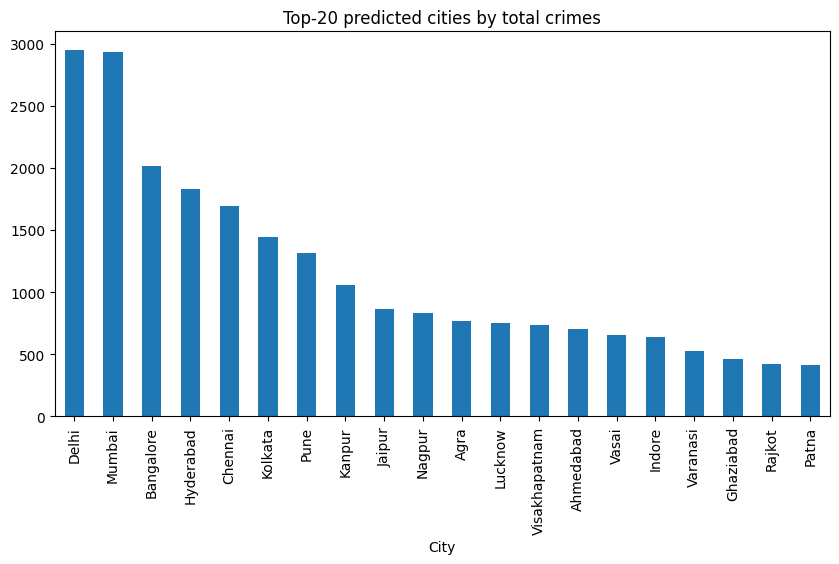

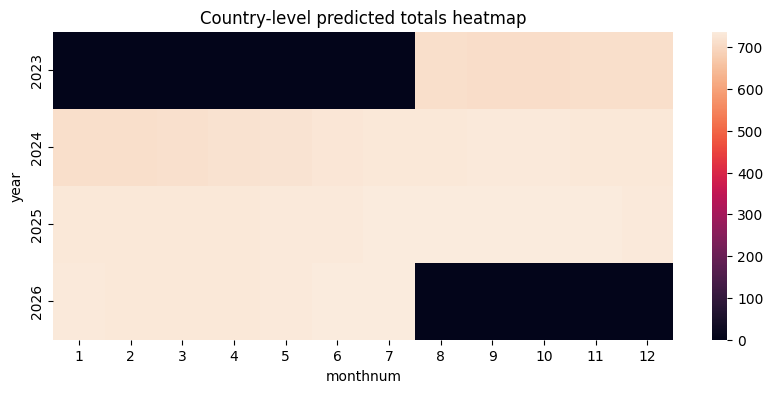

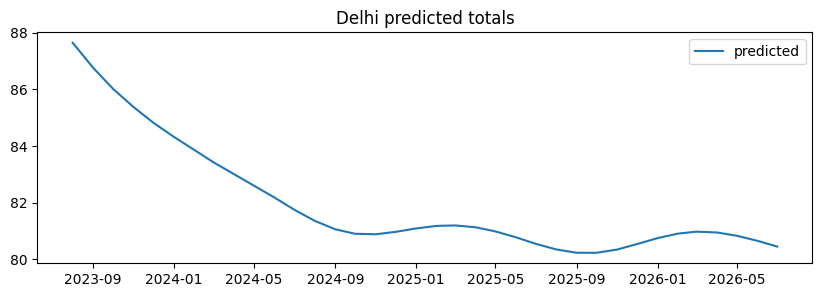

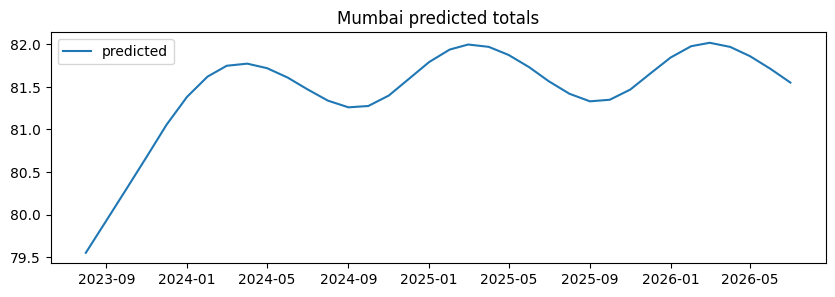

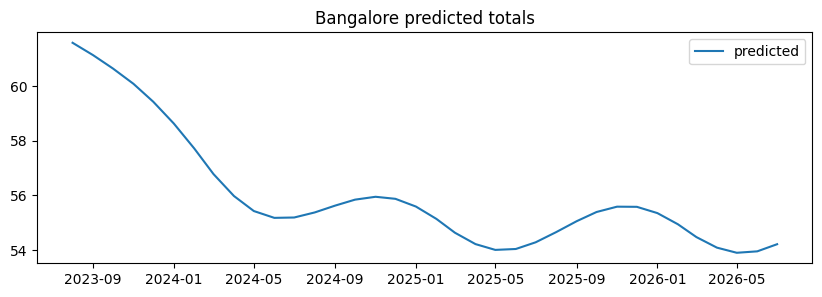

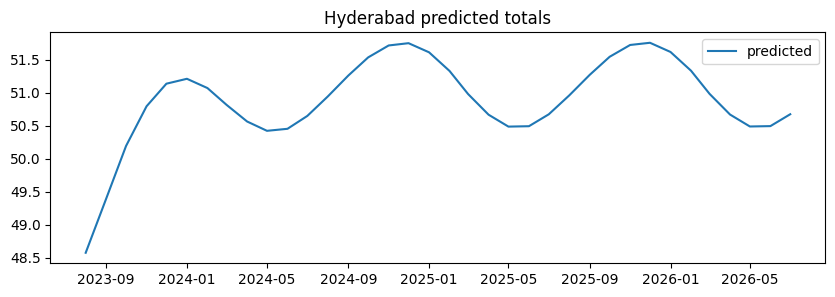

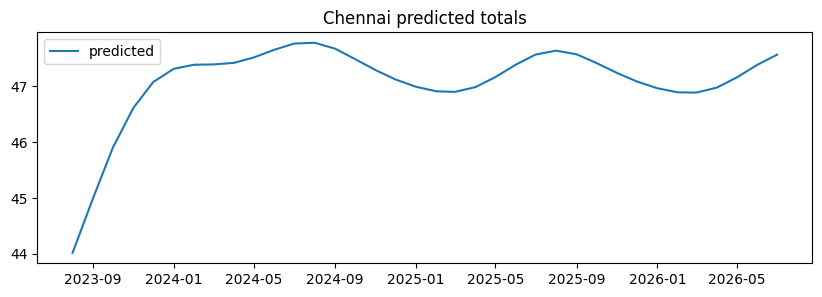

In [ ]:
# Cell 14: plotting examples
import matplotlib.pyplot as plt
pred_df = pd.read_parquet(os.path.join(OUTPUT_DIR, f'predicted_city_months_{forecast_months}m.parquet'))

# Top-20 cities bar
city_sum = pred_df.groupby('City')['pred_total'].sum().sort_values(ascending=False).head(20)
plt.figure(figsize=(10,5)); city_sum.plot.bar(); plt.title('Top-20 predicted cities by total crimes'); plt.show()

# Month heatmap (country-level by month)
month_sum = pred_df.groupby('month')['pred_total'].sum().reset_index()
month_sum['year'] = pd.to_datetime(month_sum['month']).dt.year
month_sum['monthnum'] = pd.to_datetime(month_sum['month']).dt.month
pivot = month_sum.pivot(index='year', columns='monthnum', values='pred_total').fillna(0)
plt.figure(figsize=(10,4)); import seaborn as sns
sns.heatmap(pivot, annot=False, fmt=".0f"); plt.title('Country-level predicted totals heatmap'); plt.show()

# sample city time-series true vs predicted (requires historical aggregates)
# build predicted city-month totals for a few sample cities
sample_cities = city_sum.head(5).index.tolist()
for c in sample_cities:
    dfp = pred_df[pred_df['City']==c].sort_values('month')
    plt.figure(figsize=(10,3))
    plt.plot(dfp['month'], dfp['pred_total'], label='predicted')
    plt.title(f"{c} predicted totals")
    plt.legend()
    plt.show()


## Inference

In [ ]:
# Fix classification of *_count columns into crime_count_cols vs demo_count_cols
import os, glob, joblib, pandas as pd, re

BASE = '/content/drive/MyDrive/CyberSecurity'
OUTPUT_DIR = os.path.join(BASE, 'inference_outputs')
pred_path = os.path.join(OUTPUT_DIR, 'predicted_city_months_36m.parquet')
pred_df = pd.read_parquet(pred_path)
all_count_cols = [c for c in pred_df.columns if c.endswith('_count')]

print("Total *_count columns found:", len(all_count_cols))
sample = all_count_cols[:40]
print("Sample columns:", sample)

# 1) Try to get canonical crime list from a checkpoint if available
crime_list = []
ckpt_candidates = sorted(glob.glob(os.path.join(BASE, 'checkpoints', 'multitask_model_best_epoch_*.pth')))
if ckpt_candidates:
    ck = joblib.os.path.exists(ckpt_candidates[-1]) and None
    try:
        import torch
        ckpt = torch.load(ckpt_candidates[-1], map_location='cpu')
        crime_list = ckpt.get('crime_cols', []) or ckpt.get('crime_col_names', []) or []
        print("Loaded crime list from checkpoint:", len(crime_list), "items")
    except Exception as e:
        print("Could not load crime list from checkpoint:", e)

# 2) fallback: try monthly_crime_type_props or crime_counts_smoothed
if not crime_list:
    cand = None
    for p in [
        os.path.join(BASE,'monthly_crime_type_props.parquet'),
        os.path.join(BASE,'crime_counts_smoothed.parquet'),
        os.path.join(BASE,'monthly_crime_type_props.parquet'),
    ]:
        if os.path.exists(p):
            cand = p; break
    if cand:
        try:
            dfc = pd.read_parquet(cand)
            # find the likely crime-type column
            type_col = None
            for cc in ['Crime_Description','crime','Crime','CrimeType','crime_type']:
                if cc in dfc.columns:
                    type_col = cc; break
            if type_col is None:
                # pick first string column that's not City/month
                for cc in dfc.columns:
                    if dfc[cc].dtype == object and cc.lower() not in ['city','month','date']:
                        type_col = cc; break
            if type_col:
                crime_list = sorted(dfc[type_col].dropna().astype(str).unique().tolist())
                print("Built crime_list from", cand, "type_col:", type_col, "->", len(crime_list), "types")
        except Exception as e:
            print("Couldn't read crime file candidate:", e)

# 3) build age-group list from monthly_age_group_props if available
age_bins = []
age_file = os.path.join(BASE, 'monthly_age_group_props.parquet')
if os.path.exists(age_file):
    try:
        adf = pd.read_parquet(age_file)
        if 'Age_Group' in adf.columns:
            age_bins = sorted(adf['Age_Group'].dropna().astype(str).unique().tolist())
            print("Detected age bins from monthly_age_group_props:", age_bins)
    except Exception as e:
        print("Could not read age file:", e)

# 4) Heuristic classification function
crime_set = set([c.lower() for c in crime_list])
age_set = set([c.lower() for c in age_bins])

crime_count_cols = []
demo_count_cols = []
unknown_cols = []

for col in all_count_cols:
    base = col[:-6]  # remove suffix _count
    base_clean = base.strip()
    b_low = base_clean.lower()
    classified = False
    # Exact match to known crime name
    if b_low in crime_set:
        crime_count_cols.append(col); classified = True
    # Exact match to known age bin
    elif b_low in age_set:
        demo_count_cols.append(col); classified = True
    else:
        # substring / contains matching: check if any crime name is substring of base or vice versa
        found_crime = None
        for cr in crime_list:
            cr_l = cr.lower()
            if cr_l in b_low or b_low in cr_l:
                found_crime = cr; break
        if found_crime:
            crime_count_cols.append(col); classified = True
        else:
            # check age-like pattern (e.g., "20-29", "60s", "70-79")
            if re.match(r'^\d{1,2}\-\d{1,2}$', base_clean) or re.match(r'^\d{1,2}s$', base_clean) or bool(re.search(r'\d', base_clean)) and ('-' in base_clean):
                demo_count_cols.append(col); classified = True
    if not classified:
        # try to detect gender (Male/Female)
        if any(g in b_low for g in ['male','female','fem','males','females']):
            demo_count_cols.append(col); classified = True
    if not classified:
        unknown_cols.append(col)

print("\nClassification summary:")
print("Crime count cols detected:", len(crime_count_cols))
print("Demo count cols detected:", len(demo_count_cols))
print("Unknown *_count cols:", len(unknown_cols))
print("\nSample crime_count_cols (first 20):", crime_count_cols[:20])
print("Sample demo_count_cols (first 20):", demo_count_cols[:20])
print("Sample unknown cols (first 20):", unknown_cols[:20])

# If unknowns exist, try to resolve them by asking whether they match any crime_list entries (substring)
if unknown_cols and crime_list:
    resolved = []
    for col in unknown_cols[:]:
        base = col[:-6].lower()
        for cr in crime_list:
            if base in cr.lower() or cr.lower() in base:
                crime_count_cols.append(col); resolved.append(col); break
    # remove resolved from unknown
    unknown_cols = [c for c in unknown_cols if c not in resolved]
    print("After substring resolution, newly assigned:", resolved)
    print("Remaining unknown cols:", unknown_cols[:20])

# Save classification to disk for plotting cells to use
import json
out = {
    'crime_count_cols': crime_count_cols,
    'demo_count_cols': demo_count_cols,
    'unknown_count_cols': unknown_cols,
    'crime_list_from_ckpt': crime_list,
    'age_bins_detected': age_bins
}
with open(os.path.join(OUTPUT_DIR, 'pred_column_classification.json'), 'w') as f:
    json.dump(out, f, indent=2, default=str)
print("\nSaved classification to:", os.path.join(OUTPUT_DIR, 'pred_column_classification.json'))

# Expose variables for notebook re-use
print("\nUse the lists `crime_count_cols` and `demo_count_cols` for plotting.")


Total *_count columns found: 28
Sample columns: ['ARSON_count', 'ASSAULT_count', 'BURGLARY_count', 'COUNTERFEITING_count', 'CYBERCRIME_count', 'DOMESTIC VIOLENCE_count', 'DRUG OFFENSE_count', 'EXTORTION_count', 'FIREARM OFFENSE_count', 'FRAUD_count', 'HOMICIDE_count', 'IDENTITY THEFT_count', 'ILLEGAL POSSESSION_count', 'KIDNAPPING_count', 'PUBLIC INTOXICATION_count', 'ROBBERY_count', 'SEXUAL ASSAULT_count', 'SHOPLIFTING_count', 'TRAFFIC VIOLATION_count', 'VANDALISM_count', 'VEHICLE - STOLEN_count', '10-19_count', '20-29_count', '30-39_count', '40-49_count', '50-59_count', '60-69_count', '70-79_count']
Loaded crime list from checkpoint: 21 items
Detected age bins from monthly_age_group_props: ['10-19', '20-29', '30-39', '40-49', '50-59', '60-69', '70-79']

Classification summary:
Crime count cols detected: 21
Demo count cols detected: 7
Unknown *_count cols: 0

Sample crime_count_cols (first 20): ['ARSON_count', 'ASSAULT_count', 'BURGLARY_count', 'COUNTERFEITING_count', 'CYBERCRIME_coun

In [ ]:
# ===== Cell B (FIXED): Crime-wise bars for top cities =====
import json
import pandas as pd
import matplotlib.pyplot as plt
import os

BASE = '/content/drive/MyDrive/CyberSecurity'
OUT = os.path.join(BASE, 'inference_outputs')
SAVE_DIR = os.path.join(OUT, 'top_cities')
os.makedirs(SAVE_DIR, exist_ok=True)

# Load predictions
pred_df = pd.read_parquet(os.path.join(OUT, 'predicted_city_months_36m.parquet'))

# Load column classification
with open(os.path.join(OUT, 'pred_column_classification.json'), 'r') as f:
    cls = json.load(f)

crime_cols = cls['crime_count_cols']   # ONLY crimes
print("Using crime columns:", crime_cols)

# Map column names -> clean labels
crime_label_map = {
    c: c.replace('_count', '').title()
    for c in crime_cols
}

# Top cities
top_cities = ['Delhi', 'Mumbai', 'Bangalore', 'Hyderabad', 'Kolkata']

# Add year column
pred_df['year'] = pred_df['month'].dt.year

for city in top_cities:
    city_df = pred_df[pred_df['City'] == city]
    if city_df.empty:
        print(f"Skipping {city} (no data)")
        continue

    yearly = (
        city_df
        .groupby('year')[crime_cols]
        .sum()
        .reset_index()
        .set_index('year')
    )

    # Rename columns for plotting
    yearly = yearly.rename(columns=crime_label_map)

    fig, ax = plt.subplots(figsize=(14, 6))
    yearly.T.plot(kind='bar', ax=ax)

    ax.set_title(f"{city}: Predicted crime counts per year")
    ax.set_xlabel("Crime Type")
    ax.set_ylabel("Predicted crime count")
    ax.tick_params(axis='x', rotation=90)

    plt.tight_layout()

    # Save plot
    fname = f"{city.replace(' ', '_')}_crime_by_year.png"
    save_path = os.path.join(SAVE_DIR, fname)
    fig.savefig(save_path, dpi=200, bbox_inches='tight')
    plt.close(fig)

    print(f"Saved plot: {save_path}")


Using crime columns: ['ARSON_count', 'ASSAULT_count', 'BURGLARY_count', 'COUNTERFEITING_count', 'CYBERCRIME_count', 'DOMESTIC VIOLENCE_count', 'DRUG OFFENSE_count', 'EXTORTION_count', 'FIREARM OFFENSE_count', 'FRAUD_count', 'HOMICIDE_count', 'IDENTITY THEFT_count', 'ILLEGAL POSSESSION_count', 'KIDNAPPING_count', 'PUBLIC INTOXICATION_count', 'ROBBERY_count', 'SEXUAL ASSAULT_count', 'SHOPLIFTING_count', 'TRAFFIC VIOLATION_count', 'VANDALISM_count', 'VEHICLE - STOLEN_count']
Saved plot: /content/drive/MyDrive/CyberSecurity/inference_outputs/top_cities/Delhi_crime_by_year.png
Saved plot: /content/drive/MyDrive/CyberSecurity/inference_outputs/top_cities/Mumbai_crime_by_year.png
Saved plot: /content/drive/MyDrive/CyberSecurity/inference_outputs/top_cities/Bangalore_crime_by_year.png
Saved plot: /content/drive/MyDrive/CyberSecurity/inference_outputs/top_cities/Hyderabad_crime_by_year.png
Saved plot: /content/drive/MyDrive/CyberSecurity/inference_outputs/top_cities/Kolkata_crime_by_year.png


Saved: /content/drive/MyDrive/CyberSecurity/inference_outputs/top_crimes/crime_BURGLARY_top40_2y.png


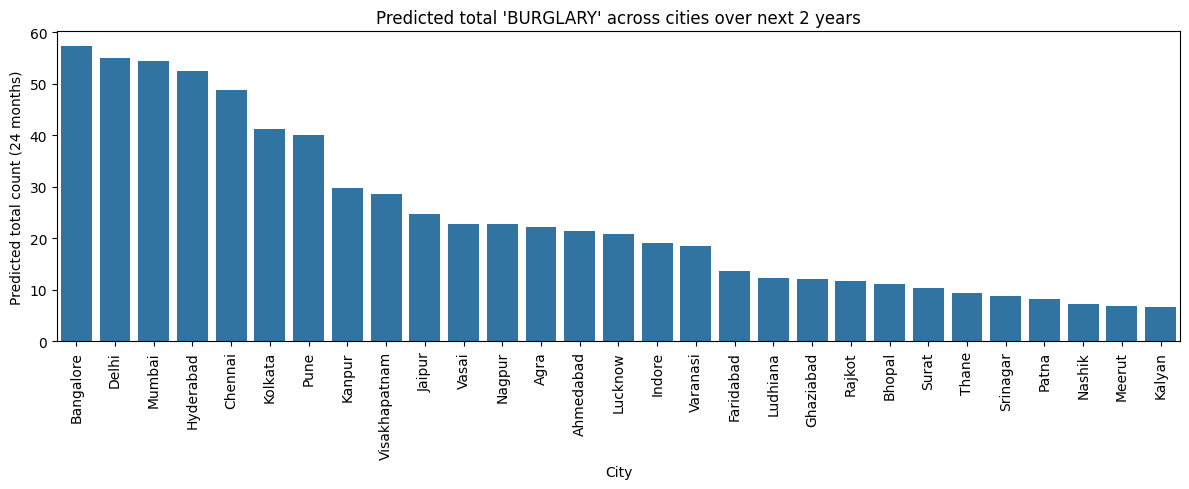

Saved: /content/drive/MyDrive/CyberSecurity/inference_outputs/top_crimes/crime_VANDALISM_top40_2y.png


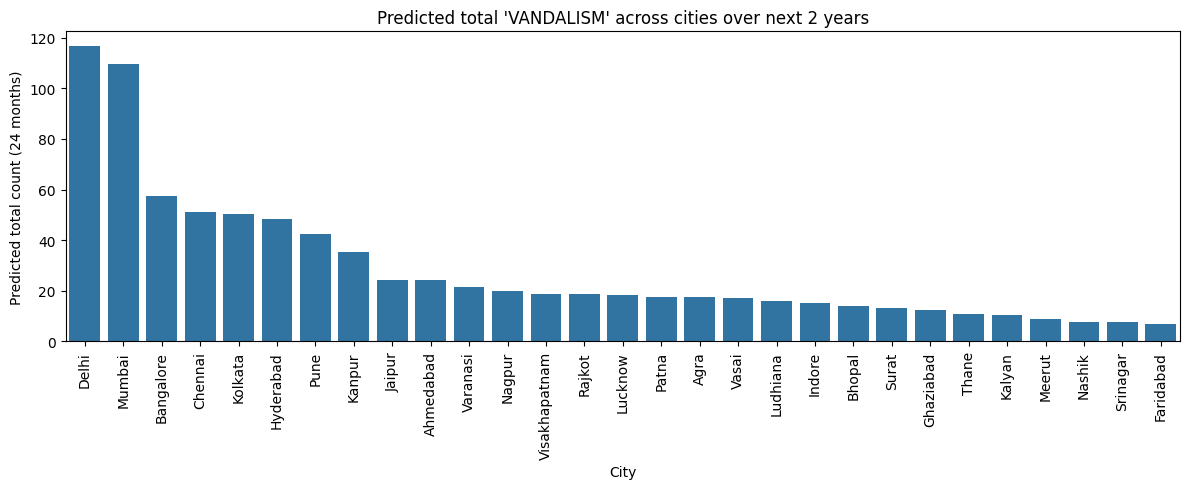

Saved: /content/drive/MyDrive/CyberSecurity/inference_outputs/top_crimes/crime_FRAUD_top40_2y.png


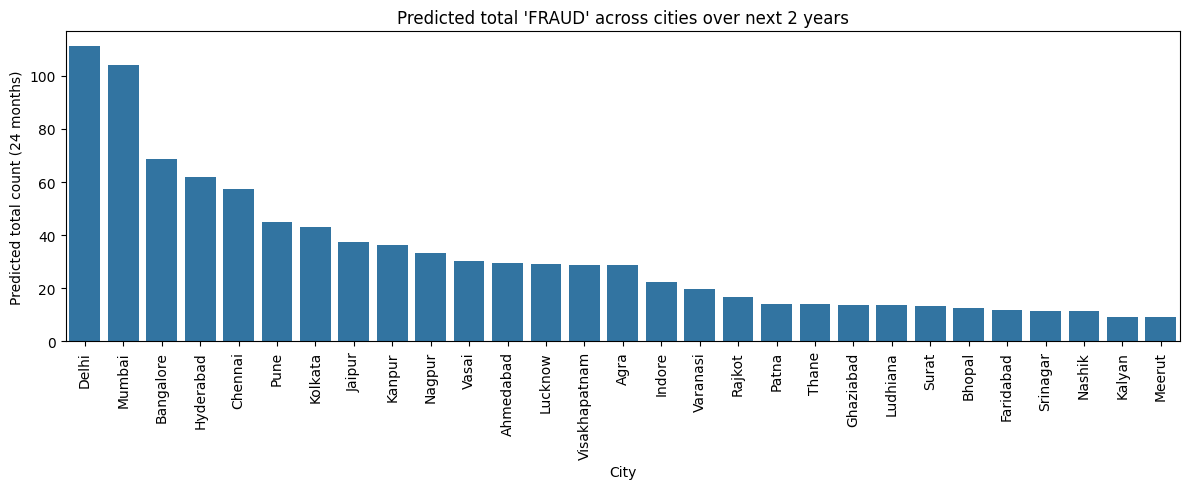

Saved: /content/drive/MyDrive/CyberSecurity/inference_outputs/top_crimes/crime_DOMESTIC VIOLENCE_top40_2y.png


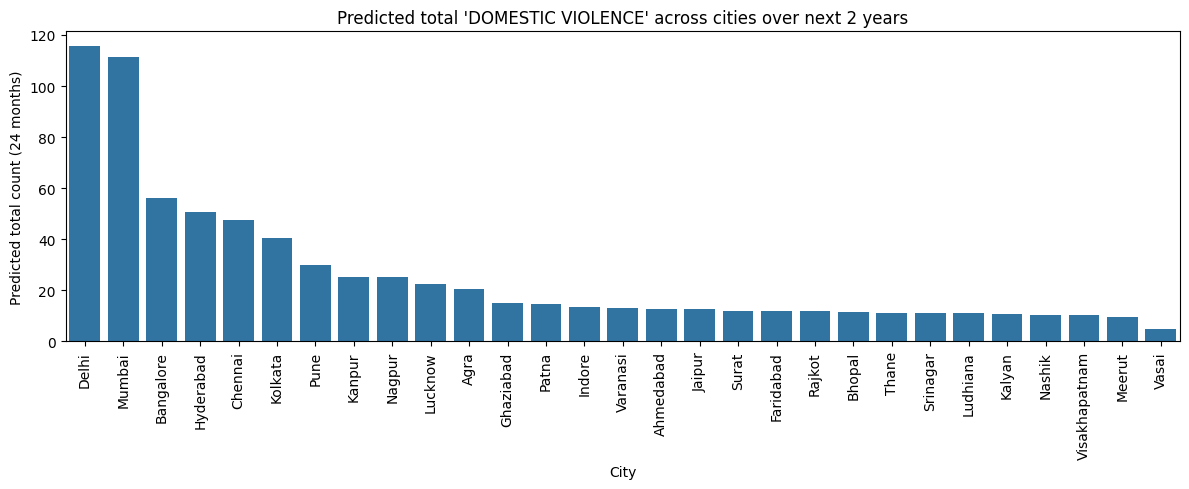

Saved: /content/drive/MyDrive/CyberSecurity/inference_outputs/top_crimes/crime_FIREARM OFFENSE_top40_2y.png


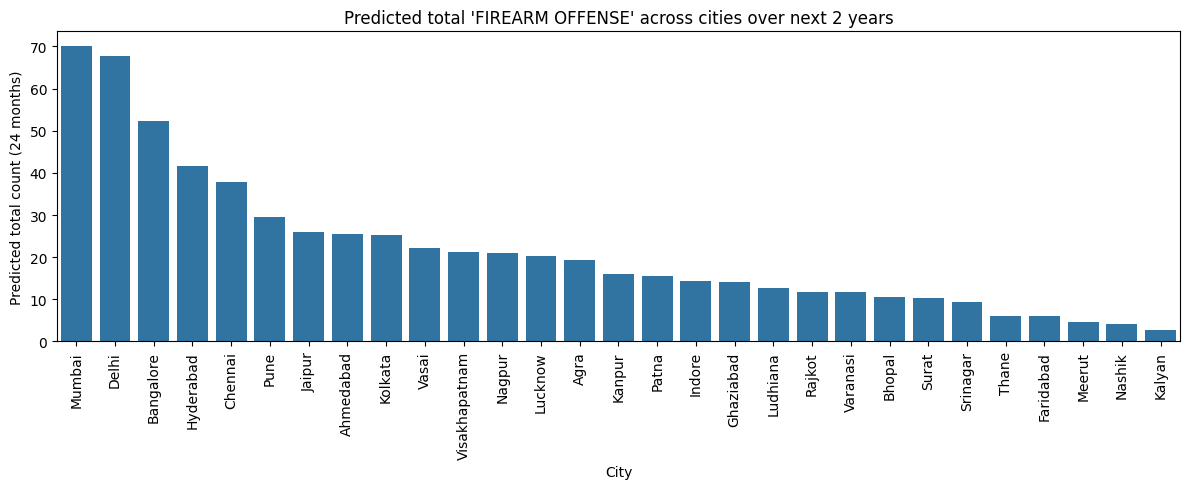

In [ ]:
# Cell C: Top 5 crimes -> for each crime: bar chart of cities (x) vs total predicted count over next 2 years (24 months)
requested_crimes = ['BURGLARY', 'VANDALISM', 'FRAUD', 'DOMESTIC VIOLENCE', 'FIREARM OFFENSE']
# find first 24 months of forecast (sorted by month)
months_sorted = sorted(pred_df['month'].unique())
first_24 = months_sorted[:24] if len(months_sorted) >= 24 else months_sorted
TOP_CRIMES_DIR = os.path.join(OUT, 'top_crimes')
os.makedirs(TOP_CRIMES_DIR, exist_ok=True)

# helper to map crime name to actual column
available_crimes = [c[:-6] for c in pred_df.columns if c.endswith('_count')]
available_crimes_lc = {c.lower(): c for c in available_crimes}

def find_crime_col(req):
    req_l = req.lower()
    # exact
    if req_l in available_crimes_lc:
        return available_crimes_lc[req_l]
    # contains
    for ac in available_crimes:
        if req_l in ac.lower(): return ac
    # startswith
    for ac in available_crimes:
        if ac.lower().startswith(req_l[:4]): return ac
    return None

for rc in requested_crimes:
    found = find_crime_col(rc)
    if found is None:
        print("Warning: crime not found in predictions:", rc)
        continue
    col = f"{found}_count"
    df24 = pred_df[pred_df['month'].isin(first_24)].groupby('City')[col].sum().reset_index().sort_values(col, ascending=False)
    # limit to top cities for readability
    top_n = 40
    df_plot = df24.head(top_n)
    fig, ax = plt.subplots(figsize=(12,5))
    sns.barplot(data=df_plot, x='City', y=col, ax=ax)
    ax.set_title(f"Predicted total '{found}' across cities over next 2 years")
    ax.set_xlabel("City")
    ax.set_ylabel("Predicted total count (24 months)")
    plt.xticks(rotation=90)
    plt.tight_layout()
    fname = os.path.join(TOP_CRIMES_DIR, f"crime_{found}_top{top_n}_2y.png")
    fig.savefig(fname, dpi=200)
    print("Saved:", fname)
    plt.show()


Saved: /content/drive/MyDrive/CyberSecurity/inference_outputs/gender_split/agegroup_by_gender_grouped.png


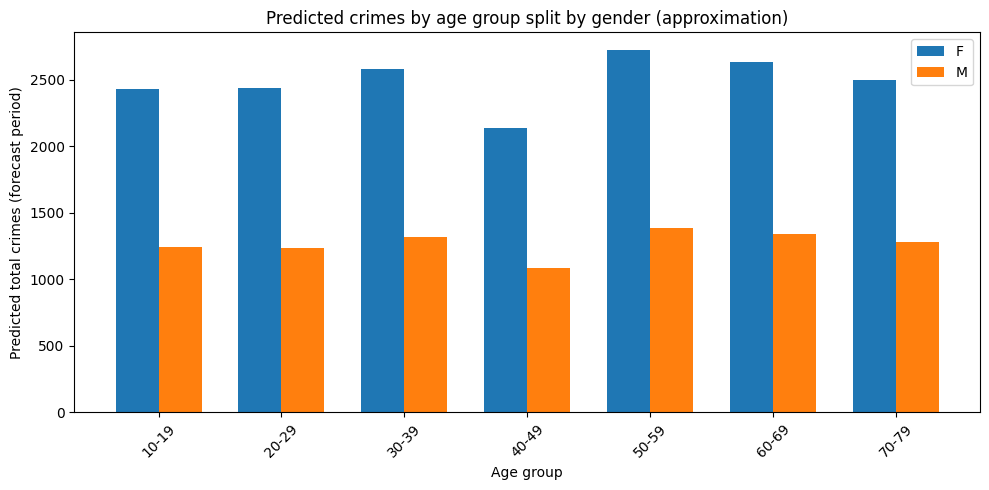

In [ ]:
# Plot: Age groups (x) split by Male/Female (stacked or grouped) — total predicted crimes across forecast period
import os, json
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

BASE = '/content/drive/MyDrive/CyberSecurity'
OUT = os.path.join(BASE, 'inference_outputs')
SAVE_DIR = os.path.join(OUT, 'gender_split')
os.makedirs(SAVE_DIR, exist_ok=True)

pred_path = os.path.join(OUT, 'predicted_city_months_36m.parquet')
cls_path = os.path.join(OUT, 'pred_column_classification.json')
age_props_path = os.path.join(BASE, 'monthly_age_group_props.parquet')
gender_props_path = os.path.join(BASE, 'monthly_gender_props.parquet')

# load
pred_df = pd.read_parquet(pred_path)
pred_df['month'] = pd.to_datetime(pred_df['month']).dt.to_period('M').dt.to_timestamp()

with open(cls_path, 'r') as f:
    cls = json.load(f)
demo_count_cols = cls.get('demo_count_cols', [])   # e.g. ['20-29_count', ...]

# Helper: ensure month and City in gender props
if not os.path.exists(gender_props_path):
    raise RuntimeError(f"monthly_gender_props.parquet not found at {gender_props_path}. Required for male/female split.")
gdf = pd.read_parquet(gender_props_path)
# Normalize gender props: expect columns Victim_Gender, gender_prop (or similar)
gdf_cols = [c.lower() for c in gdf.columns]
if 'month' in gdf.columns:
    gdf['month'] = pd.to_datetime(gdf['month']).dt.to_period('M').dt.to_timestamp()
else:
    # try to find date column
    for c in gdf.columns:
        if 'date' in c.lower() or 'month' in c.lower():
            gdf['month'] = pd.to_datetime(gdf[c]).dt.to_period('M').dt.to_timestamp(); break

# find gender prop column
gender_prop_col = None
for cand in ['gender_prop','prop','share','gender_share','genderprop']:
    if cand in gdf.columns:
        gender_prop_col = cand; break
# find gender label column
gender_label_col = None
for cand in ['Victim_Gender','victim_gender','Gender','gender','VictimGender']:
    if cand in gdf.columns:
        gender_label_col = cand; break

if gender_prop_col is None or gender_label_col is None:
    # try to inspect columns
    raise RuntimeError("monthly_gender_props.parquet doesn't have expected columns (Victim_Gender & gender_prop). Columns: " + ", ".join(gdf.columns))

# create pivot: City,month -> columns Male, Female (values = proportions)
gp = gdf.pivot_table(index=['City','month'], columns=gender_label_col, values=gender_prop_col, aggfunc='first').reset_index()
# standardize gender column names (e.g. Male, Female)
gender_cols = [c for c in gp.columns if c not in ['City','month']]

# Prepare age counts per row:
# Priority: use demo_count_cols (explicit counts in pred_df)
df = pred_df.copy()

if demo_count_cols and all(c in df.columns for c in demo_count_cols):
    # use them directly
    # build long form: for each age col, create a row with age_group and age_count
    rows = []
    for col in demo_count_cols:
        age = col[:-6]
        tmp = df[['City','month','pred_total', col]].copy().rename(columns={col:'age_count'})
        tmp['age_group'] = age
        rows.append(tmp[['City','month','age_group','age_count']])
    age_counts = pd.concat(rows, ignore_index=True)
else:
    # fallback: try age_share columns in pred_df (e.g. '20-29_share'), convert to counts
    share_cols = [c for c in df.columns if c.endswith('_share')]
    age_share_cols = [c for c in share_cols if c[:-6] in (pd.read_parquet(age_props_path)['Age_Group'].astype(str).tolist() if os.path.exists(age_props_path) else [])]
    if age_share_cols:
        rows=[]
        for col in age_share_cols:
            age = col[:-6]
            tmp = df[['City','month','pred_total', col]].copy().rename(columns={col:'age_share'})
            tmp['age_group'] = age
            tmp['age_count'] = tmp['pred_total'] * tmp['age_share']
            rows.append(tmp[['City','month','age_group','age_count']])
        age_counts = pd.concat(rows, ignore_index=True)
    else:
        # final fallback: use monthly_age_group_props.parquet to estimate age shares and multiply
        if not os.path.exists(age_props_path):
            raise RuntimeError("No age columns in pred_df and monthly_age_group_props.parquet not found to estimate age distribution.")
        adf = pd.read_parquet(age_props_path)
        adf['month'] = pd.to_datetime(adf['month']).dt.to_period('M').dt.to_timestamp()
        # unify column names
        if 'Age_Group' not in adf.columns or (not any(c.lower().startswith('age') for c in adf.columns)):
            # try find age col
            possible = [c for c in adf.columns if 'age' in c.lower()]
            if possible:
                adf = adf.rename(columns={possible[0]:'Age_Group'})
        propcand = None
        for cand in ['age_group_prop','prop','share','proportion']:
            if cand in adf.columns:
                propcand = cand; break
        if propcand is None:
            # try numeric column
            numcols = [c for c in adf.columns if pd.api.types.is_numeric_dtype(adf[c]) and c not in ['year','month']]
            if numcols:
                propcand = numcols[0]
            else:
                raise RuntimeError("monthly_age_group_props.parquet lacks a numeric proportion column.")
        adf = adf[['City','month','Age_Group',propcand]].rename(columns={propcand:'age_group_prop'})
        # merge pred_df with adf on City+month
        merged = df.merge(adf, on=['City','month'], how='left')
        # fill missing age_group_prop by nearest for city
        merged['age_group_prop'] = merged['age_group_prop'].fillna(0.0)
        merged['age_count'] = merged['pred_total'] * merged['age_group_prop']
        age_counts = merged[['City','month','Age_Group','age_count']].rename(columns={'Age_Group':'age_group'})

# Now we have age_counts with columns City, month, age_group, age_count
# Merge with gender pivot to split into genders per city-month
age_counts['month'] = pd.to_datetime(age_counts['month']).dt.to_period('M').dt.to_timestamp()
gp['month'] = pd.to_datetime(gp['month']).dt.to_period('M').dt.to_timestamp()
merged = age_counts.merge(gp, on=['City','month'], how='left')

# If some gender props missing (NaN), fill with city-level mean or global mean
for g in gender_cols:
    if merged[g].isna().sum() > 0:
        # city mean
        city_means = merged.groupby('City')[g].transform('mean')
        merged[g] = merged[g].fillna(city_means)
        merged[g] = merged[g].fillna(merged[g].mean())  # global fallback

# compute male/female counts
# identify gender column names (e.g. 'Male','Female') — take first two if more
genders = gender_cols
if len(genders) == 0:
    raise RuntimeError("No gender columns found after pivoting monthly_gender_props.")
# create columns for each gender
for g in genders:
    merged[f'age_{g}_count'] = merged['age_count'] * merged[g]

# aggregate across forecast period by age_group and gender
agg_cols = {}
for g in genders:
    merged_group = merged.groupby('age_group')[f'age_{g}_count'].sum().reset_index().rename(columns={f'age_{g}_count':'count'})
    agg_cols[g] = merged_group.set_index('age_group')['count']

agg_df = pd.DataFrame(agg_cols).fillna(0.0)
agg_df = agg_df.reset_index().rename(columns={'index':'age_group'}) if agg_df.index.name else agg_df.reset_index().rename(columns={'index':'age_group'})
if 'age_group' not in agg_df.columns:
    agg_df = agg_df.rename(columns={agg_df.columns[0]:'age_group'})

# reorder age groups naturally if they are ranges like '10-19'
def age_key(s):
    try:
        return int(str(s).split('-')[0])
    except:
        return 9999
agg_df = agg_df.sort_values(by='age_group', key=lambda col: col.map(age_key))

# Plot grouped bars
plt.figure(figsize=(10,5))
x = np.arange(len(agg_df))
width = 0.35
if len(genders) >= 2:
    g1, g2 = genders[0], genders[1]
    plt.bar(x - width/2, agg_df[g1], width, label=g1)
    plt.bar(x + width/2, agg_df[g2], width, label=g2)
else:
    # single gender column — show single bars
    g1 = genders[0]
    plt.bar(x, agg_df[g1], width, label=g1)
plt.xticks(x, agg_df['age_group'], rotation=45)
plt.xlabel("Age group")
plt.ylabel("Predicted total crimes (forecast period)")
plt.title("Predicted crimes by age group split by gender (approximation)")
plt.legend()
plt.tight_layout()
out_png = os.path.join(SAVE_DIR, 'agegroup_by_gender_grouped.png')
plt.savefig(out_png, dpi=200)
print("Saved:", out_png)
plt.show()


In [ ]:
# Cell 1: prepare per-crime per-gender counts (creates male_crime_df and female_crime_df)
import os, json
import pandas as pd, numpy as np

BASE = '/content/drive/MyDrive/CyberSecurity'
OUT = os.path.join(BASE, 'inference_outputs')
pred_path = os.path.join(OUT, 'predicted_city_months_36m.parquet')
cls_path = os.path.join(OUT, 'pred_column_classification.json')
gender_props_path = os.path.join(BASE, 'monthly_gender_props.parquet')

# load preds and classification
pred_df = pd.read_parquet(pred_path)
pred_df['month'] = pd.to_datetime(pred_df['month']).dt.to_period('M').dt.to_timestamp()
with open(cls_path, 'r') as f:
    cls = json.load(f)
crime_cols = cls.get('crime_count_cols', [])
print("Detected crime columns count:", len(crime_cols))

# load gender props
if not os.path.exists(gender_props_path):
    raise FileNotFoundError("monthly_gender_props.parquet not found at: " + gender_props_path)
gdf = pd.read_parquet(gender_props_path)
# normalize columns
if 'month' in gdf.columns:
    gdf['month'] = pd.to_datetime(gdf['month']).dt.to_period('M').dt.to_timestamp()
else:
    for c in gdf.columns:
        if 'date' in c.lower() or 'month' in c.lower():
            gdf['month'] = pd.to_datetime(gdf[c]).dt.to_period('M').dt.to_timestamp()
            break
# detect gender proportion column name & gender label name
gender_prop_col = None
gender_label_col = None
for cand in ['gender_prop','prop','share','gender_share','genderprop','value']:
    if cand in gdf.columns:
        gender_prop_col = cand; break
for cand in ['Victim_Gender','victim_gender','Gender','gender','VictimGender']:
    if cand in gdf.columns:
        gender_label_col = cand; break
# try heuristics if not found
if gender_label_col is None:
    # find likely categorical column with two unique values (male/female)
    for c in gdf.columns:
        if pd.api.types.is_object_dtype(gdf[c]) or pd.api.types.is_categorical_dtype(gdf[c]):
            if gdf[c].nunique() in (2,3):
                gender_label_col = c; break
if gender_prop_col is None:
    # find numeric columns not month/city
    numeric = [c for c in gdf.columns if pd.api.types.is_numeric_dtype(gdf[c]) and c.lower() not in ('year','month')]
    if numeric:
        # choose the one with values in [0,1] if possible
        for n in numeric:
            smin, smax = gdf[n].min(), gdf[n].max()
            if smin >= -0.01 and smax <= 1.01:
                gender_prop_col = n; break
        if gender_prop_col is None:
            gender_prop_col = numeric[0]  # fallback

if gender_label_col is None or gender_prop_col is None:
    raise RuntimeError(f"Could not detect gender label/prop columns in {gender_props_path}. Columns: {gdf.columns.tolist()}")

print("Using gender label column:", gender_label_col, "and prop column:", gender_prop_col)

# pivot gender props to City x month -> columns per gender (e.g., Male, Female)
gp = gdf.pivot_table(index=['City','month'], columns=gender_label_col, values=gender_prop_col, aggfunc='first').reset_index()
# ensure month type matches pred_df
gp['month'] = pd.to_datetime(gp['month']).dt.to_period('M').dt.to_timestamp()
gender_cols = [c for c in gp.columns if c not in ['City','month']]
print("Gender columns found:", gender_cols)

# Merge gp into pred_df by City, month
df = pred_df.merge(gp, on=['City','month'], how='left')
# fill missing gender proportions by city mean then global mean
for g in gender_cols:
    df[g] = df.groupby('City')[g].transform(lambda s: s.fillna(s.mean()))
    df[g] = df[g].fillna(df[g].mean())

# Now compute per-crime per-gender counts: for each crime column 'X_count', create columns 'X_male' and 'X_female'
male_col_suffix = '_male_count'
female_col_suffix = '_female_count'
# identify male/female labels present (prefer 'Male' and 'Female' case-insensitive)
male_label = None; female_label = None
for c in gender_cols:
    cl = str(c).lower()
    if 'male' in cl and male_label is None: male_label = c
    if 'female' in cl and female_label is None: female_label = c
# if not found, take first two columns as male/female proxies
if male_label is None or female_label is None:
    if len(gender_cols) >= 2:
        male_label = gender_cols[0]; female_label = gender_cols[1]
    elif len(gender_cols) == 1:
        male_label = gender_cols[0]; female_label = None
    else:
        raise RuntimeError("No gender columns available after pivoting; cannot split crimes by gender.")

print("Interpreting gender columns -> male_label:", male_label, "female_label:", female_label)

# Build dataframe of per-crime per-gender counts (long format)
rows = []
for idx, r in df.iterrows():
    city = r['City']; month = r['month']
    male_prop = float(r.get(male_label, 0.0))
    female_prop = float(r.get(female_label, 0.0)) if female_label is not None else (1.0 - male_prop)
    for c in crime_cols:
        if c in r.index:
            base = c[:-6]  # remove '_count'
            total_count = float(r[c])
            male_cnt = total_count * male_prop
            female_cnt = total_count * female_prop
            rows.append({'City': city, 'month': month, 'year': month.year, 'crime': base, 'male_count': male_cnt, 'female_count': female_cnt})
# make DataFrame
crime_gender_df = pd.DataFrame(rows)
print("Built crime_gender_df rows:", len(crime_gender_df))
# Save to disk for plotting cells
crime_gender_df.to_parquet(os.path.join(OUT, 'crime_gender_long.parquet'), index=False)
print("Saved crime_gender_long.parquet")


Detected crime columns count: 21
Using gender label column: Victim_Gender and prop column: gender_prop
Gender columns found: ['F', 'M', 'X']
Interpreting gender columns -> male_label: F female_label: M
Built crime_gender_df rows: 21924
Saved crime_gender_long.parquet


Years in forecast: [np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]
Top crimes selected: ['ASSAULT', 'DRUG OFFENSE', 'EXTORTION', 'ILLEGAL POSSESSION', 'VEHICLE - STOLEN', 'ROBBERY', 'KIDNAPPING', 'FRAUD', 'COUNTERFEITING', 'CYBERCRIME', 'VANDALISM', 'SHOPLIFTING', 'ARSON', 'DOMESTIC VIOLENCE', 'BURGLARY', 'TRAFFIC VIOLATION', 'HOMICIDE', 'FIREARM OFFENSE', 'PUBLIC INTOXICATION', 'SEXUAL ASSAULT']
Saved: /content/drive/MyDrive/CyberSecurity/inference_outputs/gender_by_year/male_crime_by_year_top20.png


<Figure size 1400x600 with 0 Axes>

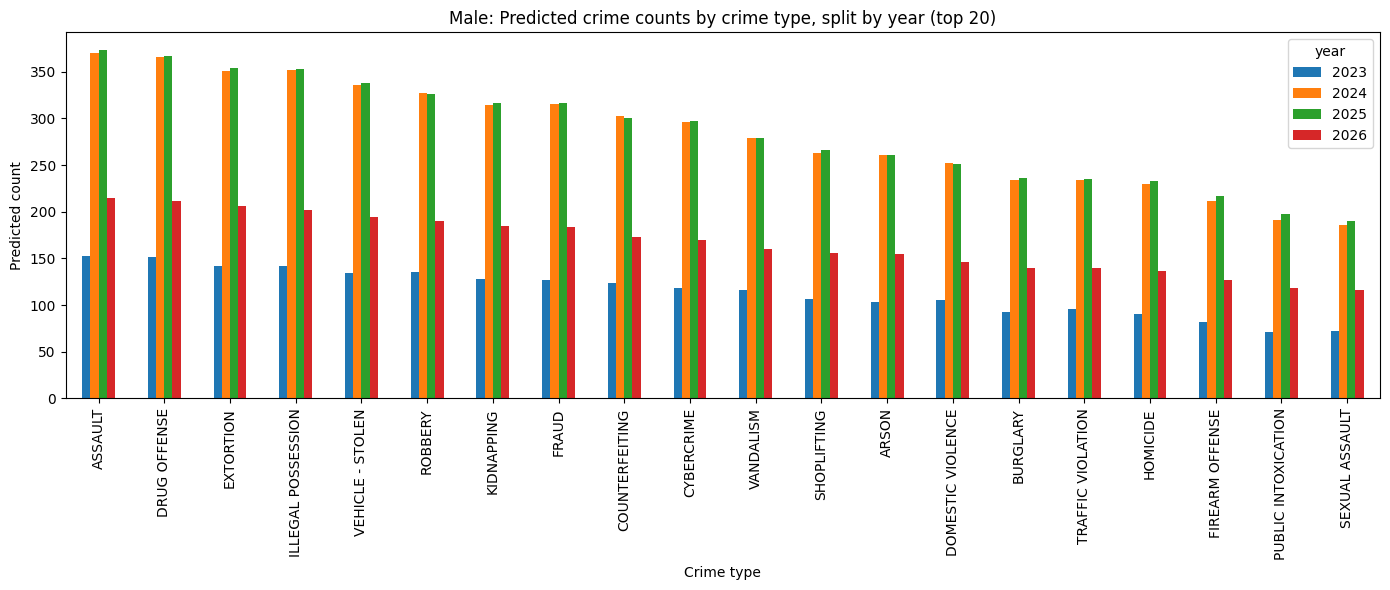

Saved: /content/drive/MyDrive/CyberSecurity/inference_outputs/gender_by_year/female_crime_by_year_top20.png


<Figure size 1400x600 with 0 Axes>

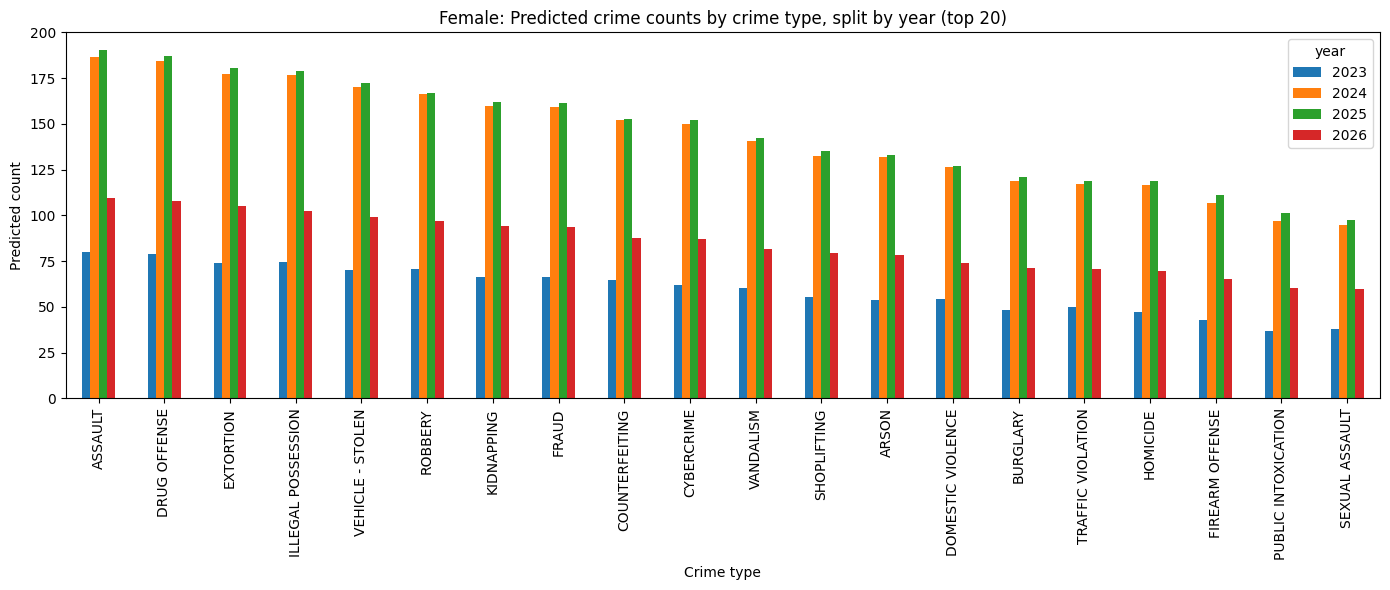

In [ ]:
# Cell 2: plot crime type (x) vs count (y) split by year for male and female separately
import os, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
BASE = '/content/drive/MyDrive/CyberSecurity'
OUT = os.path.join(BASE, 'inference_outputs')
SAVE_DIR = os.path.join(OUT, 'gender_by_year')
os.makedirs(SAVE_DIR, exist_ok=True)
df = pd.read_parquet(os.path.join(OUT, 'crime_gender_long.parquet'))

# get years present in forecast
years = sorted(df['year'].unique())
print("Years in forecast:", years)

# Aggregate: for male
male_agg = df.groupby(['year','crime'])['male_count'].sum().reset_index()
female_agg = df.groupby(['year','crime'])['female_count'].sum().reset_index()

# For plotting readability, choose top K crimes by overall sum (across genders and years)
total_by_crime = df.groupby('crime')[['male_count','female_count']].sum().sum(axis=1).sort_values(ascending=False)
topK = 20
top_crimes = total_by_crime.head(topK).index.tolist()
print("Top crimes selected:", top_crimes)

# Plot male: crime types on x, bars for each year
plt.figure(figsize=(14,6))
male_plot_df = male_agg[male_agg['crime'].isin(top_crimes)]
# pivot: rows crime, columns year
mpiv = male_plot_df.pivot(index='crime', columns='year', values='male_count').fillna(0.0)
mpiv = mpiv.loc[top_crimes]  # ensure order
mpiv.plot(kind='bar', figsize=(14,6))
plt.title("Male: Predicted crime counts by crime type, split by year (top {})".format(topK))
plt.xlabel("Crime type")
plt.ylabel("Predicted count")
plt.xticks(rotation=90)
plt.tight_layout()
out_m = os.path.join(SAVE_DIR, f"male_crime_by_year_top{topK}.png")
plt.savefig(out_m, dpi=200); print("Saved:", out_m)
plt.show()

# Plot female
plt.figure(figsize=(14,6))
female_plot_df = female_agg[female_agg['crime'].isin(top_crimes)]
fpiv = female_plot_df.pivot(index='crime', columns='year', values='female_count').fillna(0.0)
fpiv = fpiv.loc[top_crimes]
fpiv.plot(kind='bar', figsize=(14,6))
plt.title("Female: Predicted crime counts by crime type, split by year (top {})".format(topK))
plt.xlabel("Crime type")
plt.ylabel("Predicted count")
plt.xticks(rotation=90)
plt.tight_layout()
out_f = os.path.join(SAVE_DIR, f"female_crime_by_year_top{topK}.png")
plt.savefig(out_f, dpi=200); print("Saved:", out_f)
plt.show()


In [ ]:
 # Rebuild hierarchical table correctly: handle crime shares vs counts
import os, json
import pandas as pd, numpy as np

BASE = '/content/drive/MyDrive/CyberSecurity'
OUT = os.path.join(BASE, 'inference_outputs')

SAVE_DIR = os.path.join(OUT, 'table')
os.makedirs(OUT, exist_ok=True)

pred_path = os.path.join(OUT, 'predicted_city_months_36m.parquet')
cls_path  = os.path.join(OUT, 'pred_column_classification.json')
age_props_path = os.path.join(BASE, 'monthly_age_group_props.parquet')
gender_props_path = os.path.join(BASE, 'monthly_gender_props.parquet')

pred_df = pd.read_parquet(pred_path)
pred_df['month'] = pd.to_datetime(pred_df['month']).dt.to_period('M').dt.to_timestamp()

with open(cls_path,'r') as f:
    cls = json.load(f)
crime_cols = cls.get('crime_count_cols', [])
if not crime_cols:
    raise RuntimeError("No crime columns found in pred_column_classification.json")

# 1) diagnostic: are crime_cols shares or counts?
row_sums = pred_df[crime_cols].sum(axis=1)
print("Crime-columns per-row sum stats (min, mean, max):", row_sums.min(), row_sums.mean(), row_sums.max())

is_share = (row_sums.mean() > 0.0 and row_sums.mean() < 1.2)  # conservative threshold
if is_share:
    print("Detected crime columns are LIKELY SHARES (mean sum ≈ {:.3f}). We'll convert to absolute counts.".format(row_sums.mean()))
else:
    print("Detected crime columns are LIKELY ABSOLUTE COUNTS (mean sum ≈ {:.3f}). No conversion needed.".format(row_sums.mean()))

# 2) find pred_total column if needed
pred_total_col = None
candidates = ['pred_total','predicted_total','total_pred','total_prediction','total_predicted','predicted_total_count','pred_total_count','pred_sum','total']
for cand in candidates:
    if cand in pred_df.columns:
        pred_total_col = cand; break
# also try exact name 'pred_total' or 'pred_total' created earlier in notebook
if pred_total_col is None:
    # heuristic: find a numeric column that looks like total (not month/city) and has larger magnitude than shares
    numeric_cols = [c for c in pred_df.columns if pd.api.types.is_numeric_dtype(pred_df[c]) and c not in crime_cols and c.lower() not in ('year','month')]
    # pick the numeric column with largest mean
    if numeric_cols:
        means = {c: pred_df[c].abs().mean() for c in numeric_cols}
        # candidate must be noticeably larger than share scale ( > 1.5 )
        cand_sorted = sorted(means.items(), key=lambda x: -x[1])
        if cand_sorted and cand_sorted[0][1] > 1.5:
            pred_total_col = cand_sorted[0][0]

if is_share and pred_total_col is None:
    raise RuntimeError("Crime columns look like SHARES but I couldn't locate a predicted-total column in pred_df.\n"
                       "Please ensure pred_df contains a column with the predicted total crimes per City-month (e.g., 'pred_total').\n"
                       "Columns found: {}\n".format(pred_df.columns.tolist()))

if pred_total_col is not None:
    print("Using predicted-total column:", pred_total_col)

# 3) if crime_cols are shares, compute actual crime counts = pred_total * share
pred_df = pred_df.copy()
if is_share:
    for c in crime_cols:
        actual_col = c  # keep same column name but overwrite with absolute counts
        pred_df[actual_col] = pred_df[pred_total_col] * pred_df[c]
    # diagnostic
    total_counts_sample = pred_df[crime_cols].sum(axis=1).describe()
    print("After conversion, per-row total predicted crimes stats:", total_counts_sample.to_string())
else:
    print("Using crime columns directly as counts; sample sum stats:")
    print(pred_df[crime_cols].sum(axis=1).describe().to_string())

# --- now proceed to build hierarchical table as before (age*gender multipliers) ---
# load age props
adf = pd.read_parquet(age_props_path)
adf['month'] = pd.to_datetime(adf['month']).dt.to_period('M').dt.to_timestamp()
# standardize column names
if 'Age_Group' not in adf.columns:
    for c in adf.columns:
        if 'age' in c.lower() and 'group' in c.lower():
            adf = adf.rename(columns={c:'Age_Group'}); break
if 'age_group_prop' not in adf.columns:
    for c in adf.columns:
        if c not in ['City','month','Age_Group'] and pd.api.types.is_numeric_dtype(adf[c]):
            if any(k in c.lower() for k in ['prop','share','pct','percent']):
                adf = adf.rename(columns={c:'age_group_prop'}); break
adf = adf[['City','month','Age_Group','age_group_prop']].dropna(subset=['Age_Group'])

# gender props
gdf = pd.read_parquet(gender_props_path)
gdf['month'] = pd.to_datetime(gdf['month']).dt.to_period('M').dt.to_timestamp()
gender_label_col = None
for c in gdf.columns:
    if 'gender' in c.lower() and c.lower() not in ('gender_prop','age_group_prop'):
        gender_label_col = c; break
gender_prop_col = None
for c in gdf.columns:
    if c not in ['City','month', gender_label_col] and pd.api.types.is_numeric_dtype(gdf[c]):
        if any(k in c.lower() for k in ['prop','share','pct','percent']):
            gender_prop_col = c; break
if gender_prop_col is None:
    for c in gdf.columns:
        if c not in ['City','month', gender_label_col] and pd.api.types.is_numeric_dtype(gdf[c]):
            gender_prop_col = c; break
if gender_label_col is None or gender_prop_col is None:
    raise RuntimeError("Could not detect gender label/prop in monthly_gender_props.parquet; cols: " + ", ".join(gdf.columns))
gp = gdf.pivot_table(index=['City','month'], columns=gender_label_col, values=gender_prop_col, aggfunc='first').reset_index()
gender_cols = [c for c in gp.columns if c not in ['City','month']]
if len(gender_cols)==0:
    raise RuntimeError("No gender columns after pivoting gender props.")

# long form of predictions: one row per City-month-crime with absolute counts
id_vars = ['City','month']
pred_long = pred_df[id_vars + crime_cols].melt(id_vars=id_vars, value_vars=crime_cols,
                                               var_name='crime_col', value_name='crime_count')
pred_long['crime'] = pred_long['crime_col'].str.replace('_count$', '', regex=True)

# merge with age props (explodes per Age_Group)
merged = pred_long.merge(adf, on=['City','month'], how='left')

# fill missing age_group_prop with global age means
global_age_mean = adf.groupby('Age_Group')['age_group_prop'].mean().to_dict()
merged['age_group_prop'] = merged.apply(
    lambda r: r['age_group_prop'] if pd.notna(r['age_group_prop']) else global_age_mean.get(r['Age_Group'], 0.0),
    axis=1
)

# merge gender props
merged = merged.merge(gp, on=['City','month'], how='left')
# fill missing gender props (city mean then global)
for g in gender_cols:
    merged[g] = merged.groupby('City')[g].transform(lambda s: s.fillna(s.mean()))
    merged[g] = merged[g].fillna(merged[g].mean())

# compute estimated counts for each gender column (no rounding yet)
for g in gender_cols:
    merged[f'count_{g}'] = merged['crime_count'] * merged['age_group_prop'] * merged[g]

# diagnostics: sums
diag = {}
for g in gender_cols:
    col = f'count_{g}'
    diag[g] = {'sum': float(merged[col].sum()), 'min': float(merged[col].min()), 'max': float(merged[col].max()), 'mean': float(merged[col].mean())}
print("Diagnostics (estimated gender counts):")
for k,v in diag.items():
    print(k, v)

# melt gender counts and aggregate by year
count_cols = [f'count_{g}' for g in gender_cols]
melted = merged.melt(id_vars=['City','month','crime','Age_Group'], value_vars=count_cols,
                     var_name='gender_col', value_name='est_count')
melted['Gender'] = melted['gender_col'].str.replace('count_', '', regex=False)
melted['year'] = pd.to_datetime(melted['month']).dt.year

years = sorted(melted['year'].unique())
print("Years present in data:", years)

agg = (
    melted
    .groupby(['City','crime','Age_Group','Gender','year'], dropna=False)['est_count']
    .sum()
    .reset_index()
)

pivot = agg.pivot_table(index=['City','crime','Age_Group','Gender'], columns='year', values='est_count', aggfunc='sum').fillna(0.0)
out_df = pivot.reset_index()

# Save both float and integer-rounded versions
float_csv = os.path.join(OUT, 'tree_structure_float.csv')
out_df.to_csv(float_csv, index=False)
# integer rounded
int_df = out_df.copy()
# detect year columns robustly
year_cols = [c for c in int_df.columns if (isinstance(c,int) or (isinstance(c,str) and c.isnumeric()))]
for c in year_cols:
    int_df[c] = int_df[c].round().astype(int)
int_csv = os.path.join(SAVE_DIR, 'tree_structure_int_f.csv')
int_df.to_csv(int_csv, index=False)
xlsx_path = os.path.join(SAVE_DIR, 'tree_structure_ff.xlsx')
try:
    int_df.to_excel(xlsx_path, index=False)
except Exception:
    pass

print("Saved float CSV:", float_csv)
print("Saved int CSV:", int_csv)
print("Saved Excel:", xlsx_path)
print("\nSample float rows:")
display(out_df.head(12))
print("\nTotal rows:", len(out_df))


Crime-columns per-row sum stats (min, mean, max): 4.970381274819374 25.057583604569405 87.64399290084839
Detected crime columns are LIKELY ABSOLUTE COUNTS (mean sum ≈ 25.058). No conversion needed.
Using predicted-total column: pred_total
Using crime columns directly as counts; sample sum stats:
count    1044.000000
mean       25.057584
std        20.296704
min         4.970381
25%        11.202020
50%        18.438944
75%        30.757324
max        87.643993
Diagnostics (estimated gender counts):
F {'sum': 5722.472070794355, 'min': 0.0, 'max': 1.6425302028656006, 'mean': 0.09830399352013941}
M {'sum': 2918.15740748127, 'min': 0.0, 'max': 0.6461381878171648, 'mean': 0.05012982559405742}
X {'sum': 0.0, 'min': nan, 'max': nan, 'mean': nan}
Years present in data: [np.int32(2023), np.int32(2024), np.int32(2025), np.int32(2026)]
Saved float CSV: /content/drive/MyDrive/CyberSecurity/inference_outputs/tree_structure_float.csv
Saved int CSV: /content/drive/MyDrive/CyberSecurity/inference_outp

year,City,crime,Age_Group,Gender,2023,2024
0,Agra,ARSON,10-19,F,0.214543,0.579654
1,Agra,ARSON,10-19,M,0.091692,0.225564
2,Agra,ARSON,10-19,X,0.000000,0.000000
3,Agra,ARSON,20-29,F,0.308374,0.778560
4,Agra,ARSON,20-29,M,0.116047,0.320711
5,Agra,ARSON,20-29,X,0.000000,0.000000
6,Agra,ARSON,30-39,F,0.154866,0.351630
7,Agra,ARSON,30-39,M,0.083334,0.154539
8,Agra,ARSON,30-39,X,0.000000,0.000000
9,Agra,ARSON,40-49,F,0.360625,0.542629



Total rows: 12789


In [ ]:
# Build two tables (Male and Female): City | Crime | TotalCount | per-year columns
import os, json
import pandas as pd
import numpy as np

BASE = '/content/drive/MyDrive/CyberSecurity'
OUT = os.path.join(BASE, 'inference_outputs')
TABLE_DIR = os.path.join(OUT, 'tables')
os.makedirs(TABLE_DIR, exist_ok=True)

# Paths
pred_path = os.path.join(OUT, 'predicted_city_months_36m.parquet')
cls_path  = os.path.join(OUT, 'pred_column_classification.json')
gender_props_path = os.path.join(BASE, 'monthly_gender_props.parquet')

# Load predictions and classification
pred_df = pd.read_parquet(pred_path)
pred_df['month'] = pd.to_datetime(pred_df['month']).dt.to_period('M').dt.to_timestamp()

with open(cls_path, 'r') as f:
    cls = json.load(f)
crime_cols = cls.get('crime_count_cols', [])
if not crime_cols:
    raise RuntimeError("No crime columns found in pred_column_classification.json")

print("Detected crime columns:", len(crime_cols))

# Detect whether crime_cols are shares (sum per row ≈ 1) or absolute counts.
row_sums = pred_df[crime_cols].sum(axis=1)
mean_sum = float(row_sums.mean())
print("Mean sum of crime_cols per row:", mean_sum)
is_share = (mean_sum > 0.0 and mean_sum < 1.2)

# If they are shares, find a total-pred column to multiply
pred_total_col = None
if is_share:
    # candidate names
    candidates = ['pred_total','predicted_total','total_pred','total_prediction','predicted_total_count','pred_total_count','pred_sum','total','pred_total_sum']
    for cand in candidates:
        if cand in pred_df.columns:
            pred_total_col = cand; break
    # fallback: choose numeric non-crime column with large mean
    if pred_total_col is None:
        numeric_cols = [c for c in pred_df.columns if pd.api.types.is_numeric_dtype(pred_df[c]) and c not in crime_cols and c.lower() not in ('year','month')]
        if numeric_cols:
            means = {c: abs(pred_df[c]).mean() for c in numeric_cols}
            cand_sorted = sorted(means.items(), key=lambda x: -x[1])
            if cand_sorted and cand_sorted[0][1] > 1.5:  # heuristic
                pred_total_col = cand_sorted[0][0]
    if pred_total_col is None:
        raise RuntimeError("Crime columns look like shares but no predicted-total found. Add a pred_total column to pred_df.")
    print("Converting shares -> counts using column:", pred_total_col)
    # convert in-place to absolute counts
    for c in crime_cols:
        pred_df[c] = pred_df[pred_total_col] * pred_df[c]
else:
    print("Crime columns appear to be absolute counts (no conversion needed).")

# Load gender props and pivot to City-month -> columns per gender
if not os.path.exists(gender_props_path):
    raise RuntimeError("monthly_gender_props.parquet not found at: " + gender_props_path)
gdf = pd.read_parquet(gender_props_path)
gdf['month'] = pd.to_datetime(gdf['month']).dt.to_period('M').dt.to_timestamp()

# detect label + prop columns (flexible)
gender_label_col = None
for c in gdf.columns:
    if 'gender' in str(c).lower() and gdf[c].dtype == object:
        gender_label_col = c; break
if gender_label_col is None:
    # pick a categorical-like column with 2-4 uniques
    for c in gdf.columns:
        if gdf[c].dtype == object and 2 <= gdf[c].nunique() <= 6:
            gender_label_col = c; break

gender_prop_col = None
for c in gdf.columns:
    if c not in ['City','month', gender_label_col] and pd.api.types.is_numeric_dtype(gdf[c]):
        if any(k in c.lower() for k in ['prop','share','pct','percent']):
            gender_prop_col = c; break
if gender_prop_col is None:
    for c in gdf.columns:
        if c not in ['City','month', gender_label_col] and pd.api.types.is_numeric_dtype(gdf[c]):
            gender_prop_col = c; break

if gender_label_col is None or gender_prop_col is None:
    raise RuntimeError("Couldn't detect gender label or prop columns in monthly_gender_props.parquet. Columns: " + ", ".join(gdf.columns))

gp = gdf.pivot_table(index=['City','month'], columns=gender_label_col, values=gender_prop_col, aggfunc='first').reset_index()
gender_cols = [c for c in gp.columns if c not in ['City','month']]
print("Gender columns found (pivot):", gender_cols)

# Identify male and female column names (flexible)
male_col = None; female_col = None
for c in gender_cols:
    lc = str(c).lower()
    if 'male' in lc and male_col is None: male_col = c
    if 'female' in lc and female_col is None: female_col = c
# fallback: if exactly 2 columns, assume first=male, second=female
if male_col is None or female_col is None:
    if len(gender_cols) >= 2:
        male_col = male_col or gender_cols[0]
        female_col = female_col or gender_cols[1]
    elif len(gender_cols) == 1:
        male_col = gender_cols[0]
        female_col = None

print("Interpreting male_col:", male_col, "female_col:", female_col)

# Melt pred_df to long: City,month,crime_col,crime_count
id_vars = ['City','month']
pred_long = pred_df[id_vars + crime_cols].melt(id_vars=id_vars, value_vars=crime_cols,
                                               var_name='crime_col', value_name='crime_count')
pred_long['crime'] = pred_long['crime_col'].str.replace('_count$', '', regex=True)

# Merge with gender pivot
merged = pred_long.merge(gp, on=['City','month'], how='left')

# Fill missing gender props per city-month with city mean then global mean
for c in [male_col] + ([female_col] if female_col else []):
    if c is None: continue
    merged[c] = merged.groupby('City')[c].transform(lambda s: s.fillna(s.mean()))
    merged[c] = merged[c].fillna(merged[c].mean())

# If female_col missing, compute as (1 - male)
if female_col is None:
    merged['__female_prop'] = 1.0 - merged[male_col].fillna(0.0)
    female_col = '__female_prop'

# Ensure no nulls
merged[male_col] = merged[male_col].fillna(0.0)
merged[female_col] = merged[female_col].fillna(0.0)

# Compute gender-specific counts per row
merged['male_count'] = merged['crime_count'] * merged[male_col]
merged['female_count'] = merged['crime_count'] * merged[female_col]

# Add year column
merged['year'] = merged['month'].dt.year

# Aggregate by City, crime, year
male_by_year = merged.groupby(['City','crime','year'])['male_count'].sum().reset_index()
female_by_year = merged.groupby(['City','crime','year'])['female_count'].sum().reset_index()

# Pivot years into columns
male_pivot = male_by_year.pivot_table(index=['City','crime'], columns='year', values='male_count', aggfunc='sum').fillna(0.0)
female_pivot = female_by_year.pivot_table(index=['City','crime'], columns='year', values='female_count', aggfunc='sum').fillna(0.0)

# Add TotalCount column and sort descending
male_pivot['TotalCount'] = male_pivot.sum(axis=1)
female_pivot['TotalCount'] = female_pivot.sum(axis=1)

male_df = male_pivot.reset_index().sort_values('TotalCount', ascending=False)
female_df = female_pivot.reset_index().sort_values('TotalCount', ascending=False)

# Round values to integers (reasonable for counts)
year_cols = [c for c in male_df.columns if isinstance(c, int) or (isinstance(c, str) and c.isnumeric())]
for c in year_cols:
    male_df[c] = male_df[c].round().astype(int)
    female_df[c] = female_df[c].round().astype(int)
male_df['TotalCount'] = male_df['TotalCount'].round().astype(int)
female_df['TotalCount'] = female_df['TotalCount'].round().astype(int)

# Save CSV and Excel
male_csv = os.path.join(TABLE_DIR, 'male_city_crime_by_year.csv')
female_csv = os.path.join(TABLE_DIR, 'female_city_crime_by_year.csv')
male_xlsx = os.path.join(TABLE_DIR, 'male_city_crime_by_year.xlsx')
female_xlsx = os.path.join(TABLE_DIR, 'female_city_crime_by_year.xlsx')

male_df.to_csv(male_csv, index=False)
female_df.to_csv(female_csv, index=False)
try:
    male_df.to_excel(male_xlsx, index=False)
    female_df.to_excel(female_xlsx, index=False)
except Exception:
    pass

print("Saved tables to:", TABLE_DIR)
print("Male CSV:", male_csv)
print("Female CSV:", female_csv)
# Show top 8 rows for quick sanity-check
print("\nTop 8 Male rows:")
display(male_df.head(8))
print("\nTop 8 Female rows:")
display(female_df.head(8))


Detected crime columns: 21
Mean sum of crime_cols per row: 25.057583604569405
Crime columns appear to be absolute counts (no conversion needed).
Gender columns found (pivot): ['F', 'M', 'X']
Interpreting male_col: F female_col: M
Saved tables to: /content/drive/MyDrive/CyberSecurity/inference_outputs/tables
Male CSV: /content/drive/MyDrive/CyberSecurity/inference_outputs/tables/male_city_crime_by_year.csv
Female CSV: /content/drive/MyDrive/CyberSecurity/inference_outputs/tables/female_city_crime_by_year.csv

Top 8 Male rows:


year,City,crime,2023,2024,2025,2026,TotalCount
358,Mumbai,ASSAULT,21,50,51,29,151
363,Mumbai,DRUG OFFENSE,21,50,50,29,149
106,Delhi,ASSAULT,22,50,48,28,148
111,Delhi,DRUG OFFENSE,21,49,47,27,144
364,Mumbai,EXTORTION,18,44,44,26,132
370,Mumbai,KIDNAPPING,18,42,43,25,128
360,Mumbai,COUNTERFEITING,17,42,42,24,126
112,Delhi,EXTORTION,18,42,41,24,125



Top 8 Female rows:


year,City,crime,2023,2024,2025,2026,TotalCount
106,Delhi,ASSAULT,13,26,25,15,79
111,Delhi,DRUG OFFENSE,12,25,25,15,76
112,Delhi,EXTORTION,11,22,22,13,66
118,Delhi,KIDNAPPING,10,21,22,13,66
108,Delhi,COUNTERFEITING,10,21,21,12,65
358,Mumbai,ASSAULT,9,22,22,13,65
363,Mumbai,DRUG OFFENSE,9,22,22,13,65
120,Delhi,ROBBERY,10,21,21,12,64
